# 10 - Model Diagnostics and Error Analysis

## Objective

Notebook này chẩn đoán lỗi của các model trước khi hyperparameter tuning. Mục tiêu là hiểu model mắc lỗi ở đâu và vì sao, không phải retrain hoặc chọn final model.

| Diagnostic Area | Key Question |
|---|---|
| Overall error | Model nào có error thấp nhất trên original price scale? |
| Residual distribution | Residuals có centered quanh 0 hay lệch hệ thống? |
| Heteroscedasticity | Residual variance có tăng theo actual price không? |
| Price-segment bias | Low-price bị overpredict? Premium bị underpredict? |
| Log-target compression | Log-transform có nén prediction ở vùng giá cao không? |
| Outliers / data quality | Các lỗi cực đại là hard cases hợp lệ hay nhiễu dữ liệu? |
| Exploratory corrections | Hiệu chỉnh post-hoc đơn giản có giảm error pattern chính không? |

> **Important**: Notebook này không thực hiện hyperparameter tuning. Correction experiments chỉ mang tính exploratory, được ước tính trên test set, và không được report như final model performance.

### Model handling

Notebook tự động phát hiện model-target combinations thực sự có trong prediction dataframe theo pattern `pred_<Model>_<target>`. Các model được request ban đầu là CatBoost, LightGBM, và XGBoost, nhưng model nào thiếu prediction columns sẽ được skip và ghi rõ trong validation output.

**Artifacts được load từ**: `artifacts/modeling_numeric/` (output của notebook 07b)


## 1. Imports và Configuration

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import statsmodels.stats.diagnostic as sm_diag
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not available; formal heteroscedasticity tests will be skipped.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
# Configuration and paths
REQUESTED_MODELS = ["CatBoost", "LightGBM", "XGBoost"]
TARGET_CANDIDATES = ["log_target_price", "target_price"]
PRIMARY_TARGET = "log_target_price"

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "laptop_processed_numeric.csv"

ARTIFACT_DIR    = PROJECT_ROOT / "artifacts" / "modeling_numeric"
METRICS_DIR     = ARTIFACT_DIR / "metrics"
PREDICTIONS_DIR = ARTIFACT_DIR / "predictions"
COMPARISON_DIR  = ARTIFACT_DIR / "target_comparison"
DIAGNOSTICS_DIR = ARTIFACT_DIR / "model_diagnostics"
DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {"CatBoost": "CatBoost", "LightGBM": "LightGBM", "XGBoost": "XGBoost"}

def safe_filename(model_name: str, target_used: str) -> str:
    base = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(" ", ""))
    return f"{base}_{target_used}"

def expected_prediction_col(model_name: str, target_used: str) -> str:
    return f"pred_{safe_filename(model_name, target_used)}"

def format_model_target_pairs(pairs):
    return ", ".join(f"{m} + {t}" for m, t in pairs) if pairs else "None"

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"DATA_PATH      : {DATA_PATH}")
print(f"DIAGNOSTICS_DIR: {DIAGNOSTICS_DIR}")
print(f"Requested models: {REQUESTED_MODELS}")


PROJECT_ROOT   : Y:\Python\Laptop-Price-Prediction
DATA_PATH      : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
DIAGNOSTICS_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics
Requested models: ['CatBoost', 'LightGBM', 'XGBoost']


## 2. Load Predictions, Metrics và Original Data

Load artifacts đã được lưu bởi notebook 07b. Không có model retraining ở bước này.

In [3]:
# ── Kiểm tra file có sẵn ─────────────────────────────────────────────────────
print('=== Metrics files ===')
for f in sorted(METRICS_DIR.glob('*.csv')):
    print(f'  {f.name}')

print()
print('=== Predictions files ===')
for f in sorted(PREDICTIONS_DIR.glob('*.csv')):
    print(f'  {f.name}')

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Predictions files ===
  test_predictions.csv


In [4]:
# Load metrics
metrics_df = None
metrics_path = None
for candidate in ["model_metrics.csv", "metrics_df.csv", "all_metrics.csv"]:
    p = METRICS_DIR / candidate
    if p.exists():
        metrics_df = pd.read_csv(p)
        metrics_path = p
        print(f"Loaded metrics: {candidate}  shape={metrics_df.shape}")
        break

if metrics_df is None:
    raise FileNotFoundError("No metrics CSV found. Run notebook 07b first.")

metrics_df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in metrics_df.columns]
metrics_df.rename(columns={"median_ae": "median_absolute_error", "train_time_sec": "training_time_seconds"}, inplace=True)
if "mape" in metrics_df.columns and metrics_df["mape"].max() > 10:
    metrics_df["mape"] = metrics_df["mape"] / 100.0

display(metrics_df.head(10))


Loaded metrics: model_metrics.csv  shape=(16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_absolute_error,max_error,training_time_seconds,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.4887,5.5146,0.8636,0.3285,2.1175,36.1011,4.5028,0.0103
1,CatBoost,gradient_boosting,log_target_price,target_price,3.4317,5.6352,0.8575,0.2884,1.9225,37.6509,5.1633,0.0867
2,LightGBM,gradient_boosting,log_target_price,target_price,3.4507,5.7644,0.8509,0.2889,1.8571,39.7405,0.8838,0.0135
3,LightGBM,gradient_boosting,target_price,target_price,3.5544,5.7763,0.8503,0.3222,1.9777,36.2758,1.9455,0.0171
4,Random Forest,tree_ensemble,log_target_price,target_price,3.5441,5.9100,0.8433,0.3056,1.9224,36.8010,1.2685,0.1011
5,Random Forest,tree_ensemble,target_price,target_price,3.5813,5.9401,0.8417,0.3306,1.9249,38.1808,1.2279,0.1083
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7851,6.2353,0.8256,0.3233,2.0235,45.0000,1.3906,0.1262
7,Ridge,linear,target_price,target_price,4.2605,6.3395,0.8197,0.4421,2.8478,50.4027,0.0165,0.0050
8,Lasso,linear,target_price,target_price,4.2603,6.3400,0.8197,0.4420,2.8447,50.4657,0.5518,0.0026
9,ElasticNet,linear,target_price,target_price,4.2606,6.3406,0.8196,0.4421,2.8470,50.4834,1.8435,0.0025


In [5]:
# Load test predictions
predictions_raw = None
predictions_path = None
for candidate in ["test_predictions.csv", "predictions_df.csv", "all_predictions.csv"]:
    p = PREDICTIONS_DIR / candidate
    if p.exists():
        predictions_raw = pd.read_csv(p)
        predictions_path = p
        print(f"Loaded predictions: {candidate}  shape={predictions_raw.shape}")
        break

if predictions_raw is None:
    for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
        try:
            df_try = pd.read_csv(f)
            if any("pred" in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                predictions_path = f
                print(f"Fallback predictions: {f.name}  shape={predictions_raw.shape}")
                break
        except Exception:
            continue

if predictions_raw is None:
    raise FileNotFoundError("No predictions CSV found. Run notebook 07b first.")

display(predictions_raw.head())
print("Columns:", predictions_raw.columns.tolist())


Loaded predictions: test_predictions.csv  shape=(1442, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,308,9.0000,9.0137,7.3049,9.0592,7.2496,9.0540,7.4000,9.0654,7.3318,6.8778,6.2338,6.8412,6.3194,7.0218,6.7931,8.7396,7.3569
1,381,10.5000,9.9434,7.7120,10.0909,7.7676,10.1000,7.7568,10.0939,7.7633,9.0757,8.8218,9.0997,8.8671,9.2968,8.4130,9.0270,8.4374
2,1839,2.0000,3.9009,5.5218,3.9789,5.5733,3.9629,5.6547,3.9656,5.6179,2.8398,2.6547,3.0719,3.0146,3.8116,3.2011,4.0047,3.5122
3,3438,11.5000,13.6704,13.1858,13.4507,12.9666,13.4643,12.7818,13.4630,12.8764,12.8945,12.6684,12.8956,12.6720,13.2640,13.4744,13.1768,12.9445
4,251,9.2000,9.6528,7.8082,9.7203,7.9004,9.7260,7.8453,9.7413,7.8697,8.4202,7.5459,10.1088,7.2595,8.9349,9.1397,9.4542,8.5488


Columns: ['sample_id', 'y_true_price', 'pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


In [6]:
# ── Load original data (numeric only) ────────────────────────────────────────
df_orig = pd.read_csv(DATA_PATH)
TARGET_COLUMNS = ['target_price', 'log_target_price']
feature_cols = [c for c in df_orig.columns if c not in TARGET_COLUMNS]

print(f'Original data shape: {df_orig.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols[:10]} ...')

# Với numeric-only dataset, không có categorical columns để merge
# Chỉ dùng numeric features cho feature-level analysis
NUMERIC_FEATURE_COLS = df_orig[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric feature columns: {len(NUMERIC_FEATURE_COLS)}')

Original data shape: (7208, 78)
Feature columns (76): ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'no_info_brand', 'no_info_model'] ...
Numeric feature columns: 76


In [7]:
# Merge numeric features into predictions for feature-level inspection
merge_ok = False
merge_duplicate_count = 0

if "sample_id" in predictions_raw.columns:
    try:
        feature_lookup = df_orig[feature_cols].reset_index().rename(columns={"index": "sample_id"})
        predictions_with_features = predictions_raw.merge(feature_lookup, on="sample_id", how="left", validate="many_to_one")
        merge_duplicate_count = int(predictions_with_features.duplicated().sum())
        merge_ok = predictions_with_features[feature_cols[0]].notna().mean() > 0.9 if feature_cols else False
        if merge_ok:
            print(f"Feature merge successful. Shape: {predictions_with_features.shape}")
    except Exception as e:
        print(f"Feature merge failed: {e}")

if not merge_ok:
    predictions_with_features = predictions_raw.copy()
    merge_duplicate_count = int(predictions_with_features.duplicated().sum())
    print("Feature-level diagnostics will use prediction columns only; named feature merge was not reliable.")


Feature merge successful. Shape: (1442, 94)


## 3. Validation and Available Model Detection

This section validates required inputs, verifies prediction column naming, checks merge integrity, and detects which requested model-target combinations are actually analyzable.


In [8]:
import re

PRED_COL_PATTERN = re.compile(r"^pred_(?P<model>.+)_(?P<target>log_target_price|target_price)$")
validation_rows = []

def record_check(check, status, detail=""):
    validation_rows.append({"Check": check, "Status": status, "Detail": detail})
    icon = "OK" if status == "PASS" else "WARN" if status == "WARN" else "FAIL"
    print(f"[{icon}] {check}: {detail}")

def require_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    record_check(f"{name} required columns", "PASS" if not missing else "FAIL", "all present" if not missing else f"missing={missing}")
    return missing

for label, p in {"Metrics file": metrics_path, "Predictions file": predictions_path, "Original numeric dataset": DATA_PATH}.items():
    record_check(label, "PASS" if p and p.exists() else "FAIL", str(p))

require_columns(metrics_df, ["model_name", "target_used", "mae", "rmse", "mape"], "metrics_df")
actual_candidates = ["y_true_price", "actual_price", "target_price"]
actual_col = next((c for c in actual_candidates if c in predictions_raw.columns), None)
if actual_col is None:
    record_check("Actual target column", "FAIL", f"expected one of {actual_candidates}")
    raise ValueError("Cannot find actual price column in predictions. Check predictions CSV.")
record_check("Actual target column", "PASS", actual_col)
require_columns(df_orig, ["target_price", "log_target_price"], "df_orig")

prediction_cols = [c for c in predictions_raw.columns if c.startswith("pred_")]
pattern_mismatches = [c for c in prediction_cols if PRED_COL_PATTERN.match(c) is None]
record_check("Prediction column naming pattern", "PASS" if not pattern_mismatches else "WARN", "all prediction columns match" if not pattern_mismatches else f"non-matching columns={pattern_mismatches}")

available_model_targets = []
skipped_model_targets = []
for model_name in REQUESTED_MODELS:
    for target_used in TARGET_CANDIDATES:
        col = expected_prediction_col(model_name, target_used)
        if col in predictions_raw.columns:
            available_model_targets.append((model_name, target_used))
        else:
            skipped_model_targets.append((model_name, target_used, col))

SELECTED_MODELS = [m for m in REQUESTED_MODELS if any(pair[0] == m for pair in available_model_targets)]
ANALYZED_TARGETS = [t for t in TARGET_CANDIDATES if any(pair[1] == t for pair in available_model_targets)]
record_check("Available requested model-target combinations", "PASS" if available_model_targets else "FAIL", format_model_target_pairs(available_model_targets))
if not available_model_targets:
    raise ValueError("No requested model-target prediction columns are available for diagnostics.")

for model_name in REQUESTED_MODELS:
    missing_for_model = [t for m, t, _ in skipped_model_targets if m == model_name]
    if missing_for_model and model_name not in SELECTED_MODELS:
        record_check(f"{model_name} availability", "WARN", "skipped because prediction columns were unavailable")
    elif missing_for_model:
        record_check(f"{model_name} partial availability", "WARN", f"missing targets={missing_for_model}")

record_check("Duplicated rows after feature merge", "PASS" if merge_duplicate_count == 0 else "WARN", f"duplicate rows={merge_duplicate_count}")
key_cols = [actual_col] + [expected_prediction_col(m, t) for m, t in available_model_targets]
missing_report = predictions_raw[key_cols].isna().sum().loc[lambda s: s > 0]
record_check("Missing values in key columns", "PASS" if missing_report.empty else "WARN", "none" if missing_report.empty else missing_report.to_dict())

non_positive_actual = int((predictions_raw[actual_col] <= 0).sum())
record_check("Actual target values positive", "PASS" if non_positive_actual == 0 else "FAIL", f"non-positive rows={non_positive_actual}")
non_positive_pred = {col: int((predictions_raw[col] <= 0).sum()) for col in key_cols[1:] if int((predictions_raw[col] <= 0).sum()) > 0}
record_check("Predicted values positive", "PASS" if not non_positive_pred else "WARN", "all positive" if not non_positive_pred else str(non_positive_pred))
if non_positive_actual:
    raise ValueError("Actual prices must be positive for percentage and ratio diagnostics.")
if non_positive_pred:
    print("Warning: non-positive predictions are retained for diagnostics and flagged as data/model quality issues.")

validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(DIAGNOSTICS_DIR / "validation_checks.csv", index=False)
print("\nAnalyzed models:", SELECTED_MODELS)
print("Analyzed model-target pairs:", available_model_targets)
print("Saved: validation_checks.csv")
display(validation_df)


[OK] Metrics file: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
[OK] Predictions file: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv
[OK] Original numeric dataset: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
[OK] metrics_df required columns: all present
[OK] Actual target column: y_true_price
[OK] df_orig required columns: all present
[OK] Prediction column naming pattern: all prediction columns match
[OK] Available requested model-target combinations: CatBoost + log_target_price, CatBoost + target_price, LightGBM + log_target_price, LightGBM + target_price
[WARN] XGBoost availability: skipped because prediction columns were unavailable
[OK] Duplicated rows after feature merge: duplicate rows=0
[OK] Missing values in key columns: none
[OK] Actual target values positive: non-positive rows=0
[WARN] Predicted values positive: {'pred_CatBoost_target_price': 1, 'pred_L

,Check,Status,Detail
0,Metrics file,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
1,Predictions file,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
2,Original numeric dataset,PASS,Y:\Python\Laptop-Price-Prediction\data\process...
3,metrics_df required columns,PASS,all present
4,Actual target column,PASS,y_true_price
5,df_orig required columns,PASS,all present
6,Prediction column naming pattern,PASS,all prediction columns match
7,Available requested model-target combinations,PASS,"CatBoost + log_target_price, CatBoost + target..."
8,XGBoost availability,WARN,skipped because prediction columns were unavai...
9,Duplicated rows after feature merge,PASS,duplicate rows=0


## 4. Build Diagnostic Error Dataset

Reshape predictions từ wide format sang long format (một dòng mỗi sample x available model-target combination). Missing prediction columns are reported in validation and skipped.


In [9]:
# Build long-format diagnostic dataframe from available prediction columns
print(f"Actual price column: {actual_col}")

def compute_error_columns(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted
    abs_error = np.abs(residual)
    return {
        "residual": residual,
        "absolute_error": abs_error,
        "squared_error": residual ** 2,
        "percentage_error": residual / (actual + 1e-9),
        "absolute_percentage_error": abs_error / (actual + 1e-9),
        "prediction_ratio": predicted / (actual + 1e-9),
    }

diag_frames = []
sample_id = predictions_raw["sample_id"].values if "sample_id" in predictions_raw.columns else np.arange(len(predictions_raw))
actual_values = predictions_raw[actual_col].astype(float).values

for model_name, target_used in available_model_targets:
    col = expected_prediction_col(model_name, target_used)
    predicted_values = predictions_raw[col].astype(float).values
    err = compute_error_columns(actual_values, predicted_values)
    diag_frames.append(pd.DataFrame({
        "sample_id": sample_id,
        "actual_price": actual_values,
        "predicted_price": predicted_values,
        "model_name": model_name,
        "target_used": target_used,
        **err,
    }))

diag_df = pd.concat(diag_frames, ignore_index=True)
print(f"Diagnostic dataframe shape: {diag_df.shape}")
print(f"Models included: {format_model_target_pairs(available_model_targets)}")


Actual price column: y_true_price
Diagnostic dataframe shape: (5768, 11)
Models included: CatBoost + log_target_price, CatBoost + target_price, LightGBM + log_target_price, LightGBM + target_price


In [10]:
# Add price segments
q25, q50, q75 = np.quantile(predictions_raw[actual_col].values, [0.25, 0.50, 0.75])
print(f"Price quantiles: Q25={q25:,.0f}  Q50={q50:,.0f}  Q75={q75:,.0f}")

def assign_segment(price):
    if price <= q25:
        return "Low"
    if price <= q50:
        return "Mid"
    if price <= q75:
        return "High"
    return "Premium"

diag_df["price_segment"] = diag_df["actual_price"].apply(assign_segment)
diag_df["price_segment"] = pd.Categorical(diag_df["price_segment"], categories=["Low", "Mid", "High", "Premium"], ordered=True)

PRIMARY_MODEL = next((m for m, t in available_model_targets if t == PRIMARY_TARGET), available_model_targets[0][0])
if (PRIMARY_MODEL, PRIMARY_TARGET) not in available_model_targets:
    PRIMARY_TARGET = next(t for m, t in available_model_targets if m == PRIMARY_MODEL)

print(f"Primary diagnostic pair: {PRIMARY_MODEL} + {PRIMARY_TARGET}")
main_mask = (diag_df["model_name"] == PRIMARY_MODEL) & (diag_df["target_used"] == PRIMARY_TARGET)
print(diag_df[main_mask]["price_segment"].value_counts().sort_index())

diag_df.to_csv(DIAGNOSTICS_DIR / "diagnostic_errors_long.csv", index=False)
print("\nSaved: diagnostic_errors_long.csv")


Price quantiles: Q25=6  Q50=11  Q75=19
Primary diagnostic pair: CatBoost + log_target_price
price_segment
Low        369
Mid        353
High       361
Premium    359
Name: count, dtype: int64

Saved: diagnostic_errors_long.csv


## 4. Overall Error Diagnostics

Tóm tắt các thống kê error chính cho từng model variant. Ngoài MAE, RMSE, MAPE, còn track thêm:

- **Mean / median residual**: prediction có centered quanh 0 không, hay có systematic bias?
- **Underprediction rate**: tỷ lệ cases mà `actual > predicted`
- **Severe error rate**: tỷ lệ với absolute percentage error > 50%
- **Extreme error rate**: tỷ lệ với absolute percentage error > 100%

In [11]:
def compute_error_metrics(actual, predicted, residual=None, ape=None):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted if residual is None else np.asarray(residual, dtype=float)
    ape = np.abs(residual) / (actual + 1e-9) if ape is None else np.asarray(ape, dtype=float)
    return {
        "n": len(actual),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "mape": mean_absolute_percentage_error(actual, predicted),
        "median_absolute_error": median_absolute_error(actual, predicted),
        "mean_residual": residual.mean(),
        "median_residual": np.median(residual),
        "residual_std": residual.std(),
        "underprediction_rate": (residual > 0).mean(),
        "overprediction_rate": (residual < 0).mean(),
        "severe_error_rate": (ape > 0.50).mean(),
        "extreme_error_rate": (ape > 1.00).mean(),
    }

summary_rows = []
for (model_name, target_used), grp in diag_df.groupby(["model_name", "target_used"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    summary_rows.append({"model_name": model_name, "target_used": target_used, **metrics})

summary_df = pd.DataFrame(summary_rows).sort_values("rmse").reset_index(drop=True)
summary_df.to_csv(DIAGNOSTICS_DIR / "diagnostic_model_error_summary.csv", index=False)
print(f"=== Overall Error Summary ({format_model_target_pairs(available_model_targets)}) ===")
display(summary_df)


=== Overall Error Summary (CatBoost + log_target_price, CatBoost + target_price, LightGBM + log_target_price, LightGBM + target_price) ===


,model_name,target_used,n,mae,rmse,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
0,CatBoost,target_price,1442,3.4887,5.5146,0.3285,2.1175,0.2254,-0.1651,5.5100,0.4743,0.5257,0.1581,0.0451
1,CatBoost,log_target_price,1442,3.4317,5.6352,0.2884,1.9225,0.8198,0.1138,5.5753,0.5160,0.4840,0.1297,0.0250
2,LightGBM,log_target_price,1442,3.4507,5.7644,0.2889,1.8571,0.6891,0.1024,5.7230,0.5222,0.4778,0.1227,0.0333
3,LightGBM,target_price,1442,3.5544,5.7763,0.3222,1.9777,0.1876,-0.1180,5.7732,0.4840,0.5160,0.1463,0.0430


In [12]:
# Interpretation for each available model-target pair
for _, row in summary_df.iterrows():
    print(f"=== {row['model_name']} + {row['target_used']} ===")
    print(f"  MAE={row['mae']:,.2f}  RMSE={row['rmse']:,.2f}  MAPE={row['mape']:.1%}")
    print(f"  Mean residual   : {row['mean_residual']:,.0f}")
    print(f"  Median residual : {row['median_residual']:,.0f}")
    mr = row["mean_residual"]
    if abs(mr) < 1e5:
        print("  Residuals are roughly centered around zero.")
    elif mr > 0:
        print("  Positive mean residual: model tends to underpredict.")
    else:
        print("  Negative mean residual: model tends to overpredict.")
    print(f"  Underprediction rate: {row['underprediction_rate']:.1%}")
    print(f"  Severe error rate (APE>50%): {row['severe_error_rate']:.1%}")
    print(f"  Extreme error rate (APE>100%): {row['extreme_error_rate']:.1%}")
    print()


=== CatBoost + target_price ===
  MAE=3.49  RMSE=5.51  MAPE=32.9%
  Mean residual   : 0
  Median residual : -0
  Residuals are roughly centered around zero.
  Underprediction rate: 47.4%
  Severe error rate (APE>50%): 15.8%
  Extreme error rate (APE>100%): 4.5%

=== CatBoost + log_target_price ===
  MAE=3.43  RMSE=5.64  MAPE=28.8%
  Mean residual   : 1
  Median residual : 0
  Residuals are roughly centered around zero.
  Underprediction rate: 51.6%
  Severe error rate (APE>50%): 13.0%
  Extreme error rate (APE>100%): 2.5%

=== LightGBM + log_target_price ===
  MAE=3.45  RMSE=5.76  MAPE=28.9%
  Mean residual   : 1
  Median residual : 0
  Residuals are roughly centered around zero.
  Underprediction rate: 52.2%
  Severe error rate (APE>50%): 12.3%
  Extreme error rate (APE>100%): 3.3%

=== LightGBM + target_price ===
  MAE=3.55  RMSE=5.78  MAPE=32.2%
  Mean residual   : 0
  Median residual : -0
  Residuals are roughly centered around zero.
  Underprediction rate: 48.4%
  Severe error rat

### Interpretation - Overall Model Performance

The summary above shows which available model-target combinations have the lowest global MAE/RMSE and whether their residuals are centered. This matters because a low aggregate error can still hide directional bias. In the tuning notebook, keep global metrics but select candidates using segment metrics and bias checks as tie-breakers.


## 5. Heteroscedasticity Diagnosis

**Heteroscedasticity** nghĩa là residual variance không đồng đều theo dải giá. Nếu error tăng khi actual price tăng, model kém tin cậy hơn ở vùng giá cao.

> Với tree-based models, heteroscedasticity không invalidate model, nhưng ảnh hưởng đến cách diễn giải RMSE và gợi ý nên dùng segment-aware evaluation hoặc sample weighting khi tuning.

Chẩn đoán qua:
1. Scatter plot residuals vs actual price
2. Binned residual variance table
3. Spearman correlation tests

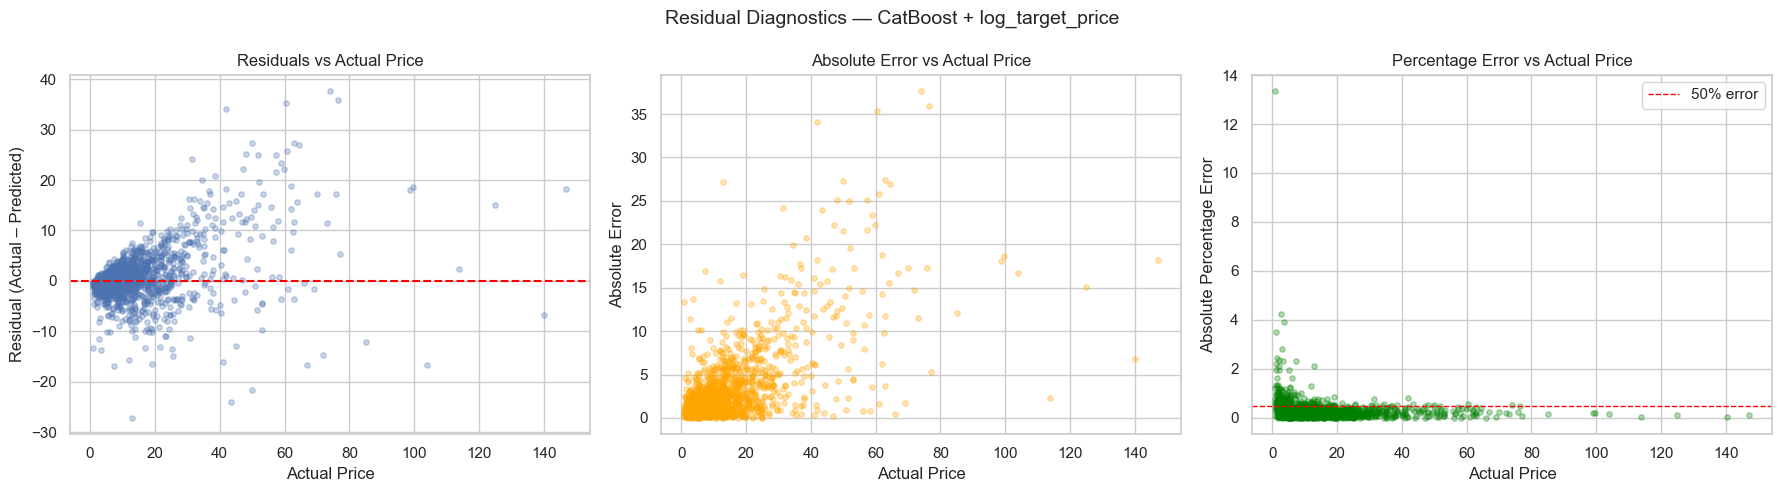

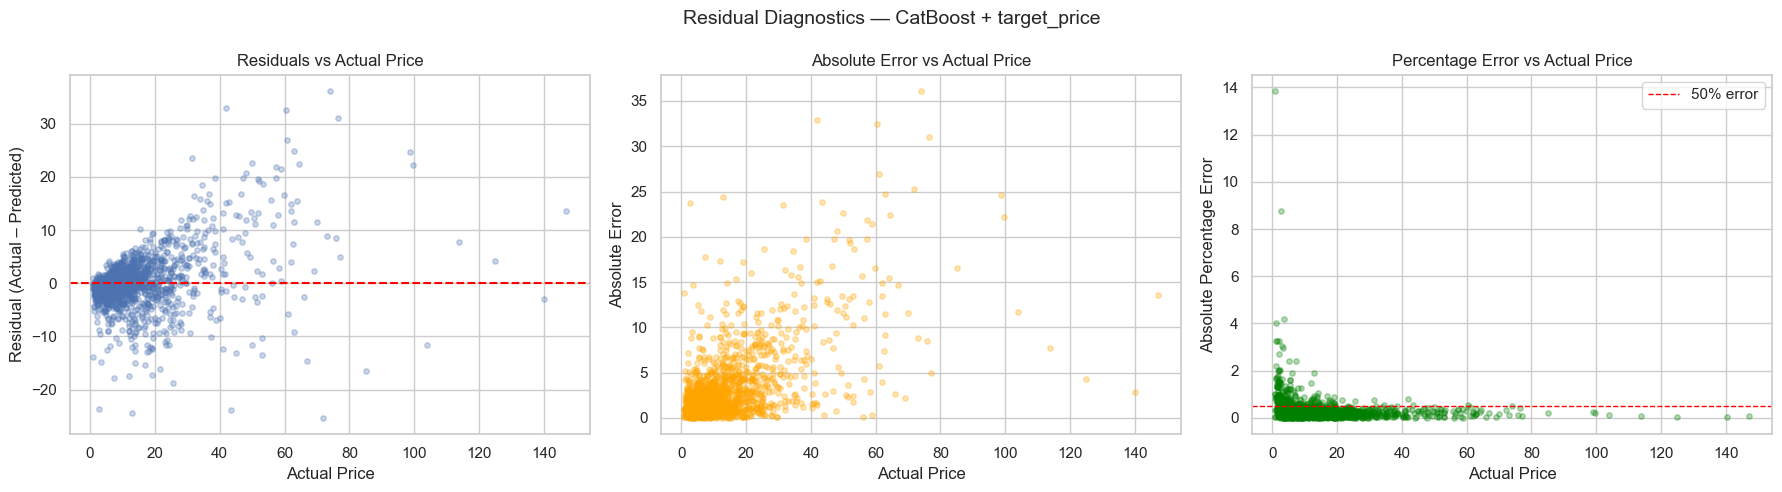

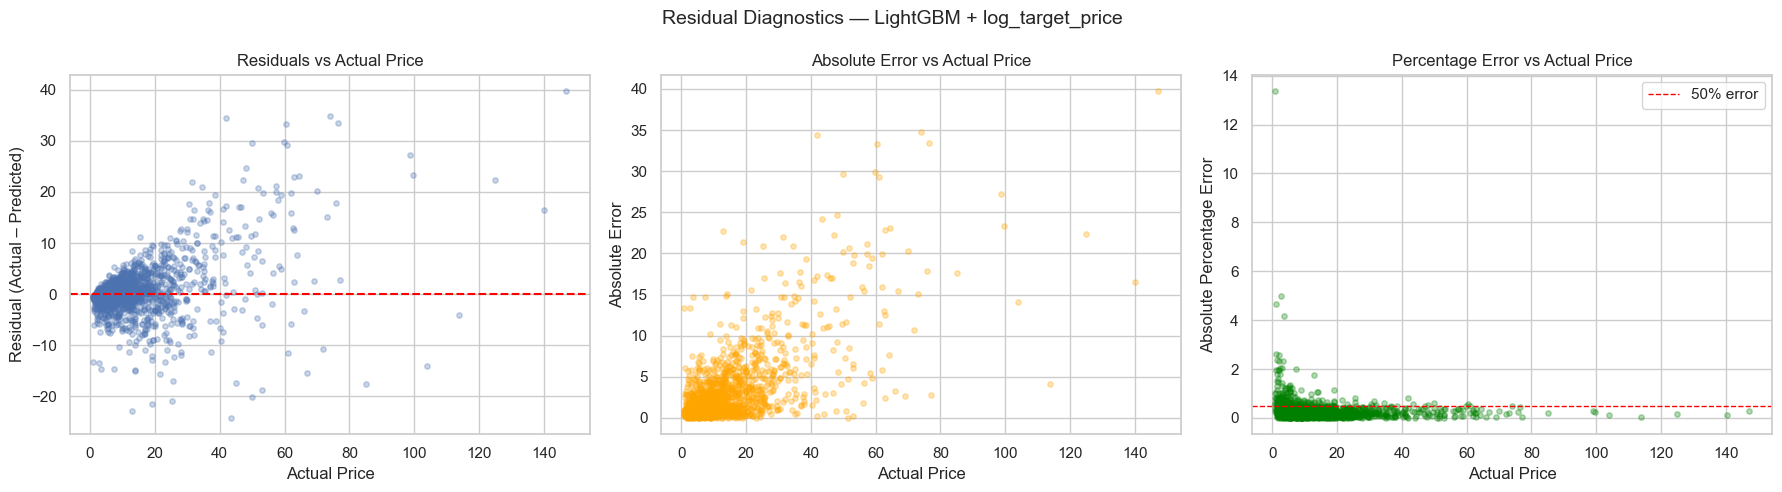

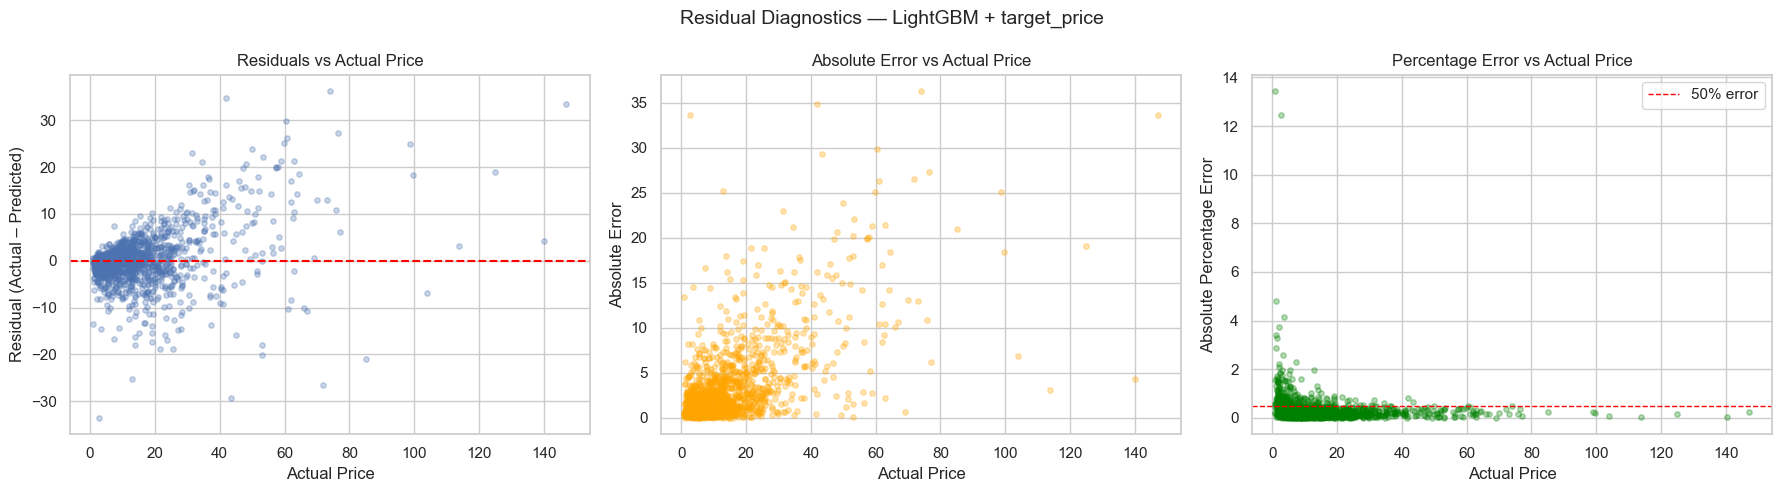

In [13]:
def plot_heteroscedasticity(diag_df, model_name, target_used, save_dir):
    """Three residual scatter plots for one model variant."""
    mask  = (diag_df['model_name'] == model_name) & (diag_df['target_used'] == target_used)
    grp   = diag_df[mask]
    label = f'{model_name} + {target_used}'
    fn    = safe_filename(model_name, target_used)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Residual Diagnostics — {label}', fontsize=14)

    axes[0].scatter(grp['actual_price'], grp['residual'], alpha=0.3, s=15)
    axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Residual (Actual – Predicted)')
    axes[0].set_title('Residuals vs Actual Price')

    axes[1].scatter(grp['actual_price'], grp['absolute_error'], alpha=0.3, s=15, color='orange')
    axes[1].set_xlabel('Actual Price')
    axes[1].set_ylabel('Absolute Error')
    axes[1].set_title('Absolute Error vs Actual Price')

    axes[2].scatter(grp['actual_price'], grp['absolute_percentage_error'], alpha=0.3, s=15, color='green')
    axes[2].axhline(0.5, color='red', linewidth=1, linestyle='--', label='50% error')
    axes[2].set_xlabel('Actual Price')
    axes[2].set_ylabel('Absolute Percentage Error')
    axes[2].set_title('Percentage Error vs Actual Price')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(save_dir / f'heteroscedasticity_{fn}.png', dpi=150, bbox_inches='tight')
    plt.show()


for model_name, target_used in available_model_targets:
    plot_heteroscedasticity(diag_df, model_name, target_used, DIAGNOSTICS_DIR)

In [14]:
# Binned residual variance table
het_rows = []
for (model_name, target_used), grp in diag_df.groupby(["model_name", "target_used"], observed=True):
    grp = grp.copy()
    grp["price_bin"] = pd.qcut(grp["actual_price"], q=10, duplicates="drop")
    for bin_label, bin_grp in grp.groupby("price_bin", observed=True):
        metrics = compute_error_metrics(bin_grp["actual_price"], bin_grp["predicted_price"], bin_grp["residual"])
        het_rows.append({
            "model_name": model_name,
            "target_used": target_used,
            "price_bin": str(bin_label),
            "price_min": bin_grp["actual_price"].min(),
            "price_max": bin_grp["actual_price"].max(),
            "count": len(bin_grp),
            "residual_std": bin_grp["residual"].std(),
            "absolute_error_mean": bin_grp["absolute_error"].mean(),
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
        })
het_df = pd.DataFrame(het_rows)
het_df.to_csv(DIAGNOSTICS_DIR / "heteroscedasticity_binned_error_summary.csv", index=False)

for model_name in SELECTED_MODELS:
    if (model_name, PRIMARY_TARGET) not in available_model_targets:
        continue
    print(f"=== Binned Residual Variance - {model_name} + {PRIMARY_TARGET} ===")
    display(het_df[(het_df["model_name"] == model_name) & (het_df["target_used"] == PRIMARY_TARGET)][["price_bin", "price_min", "price_max", "count", "residual_std", "absolute_error_mean", "rmse", "mape"]])
    print()


=== Binned Residual Variance - CatBoost + log_target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
0,"(0.999, 3.2]",1.0000,3.2000,152,1.9000,1.3521,2.2288,0.7012
1,"(3.2, 4.91]",3.2490,4.9000,137,1.7649,1.3609,2.0141,0.3371
2,"(4.91, 6.5]",4.9500,6.5000,147,2.2029,1.4869,2.2716,0.2616
3,"(6.5, 8.44]",6.6000,8.4000,141,2.6196,1.8548,2.6104,0.2506
4,"(8.44, 10.7]",8.4990,10.7000,145,2.8750,2.3034,2.8676,0.2435
5,"(10.7, 13.49]",10.8000,13.4900,145,4.2216,2.8348,4.2075,0.2331
6,"(13.49, 16.891]",13.5000,16.8700,142,4.0989,3.1726,4.1038,0.2127
7,"(16.891, 21.997]",16.9000,21.9900,144,4.6527,3.6875,4.6558,0.1937
8,"(21.997, 31.43]",21.9990,30.8900,144,5.8039,4.9917,6.1212,0.1938
9,"(31.43, 146.99]",31.4900,146.9900,145,11.3873,11.2486,13.9194,0.2364



=== Binned Residual Variance - LightGBM + log_target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
20,"(0.999, 3.2]",1.0000,3.2000,152,2.0644,1.3691,2.3561,0.7053
21,"(3.2, 4.91]",3.2490,4.9000,137,1.9427,1.4582,2.1511,0.3610
22,"(4.91, 6.5]",4.9500,6.5000,147,2.1514,1.5211,2.2213,0.2674
23,"(6.5, 8.44]",6.6000,8.4000,141,2.4434,1.7606,2.4350,0.2382
24,"(8.44, 10.7]",8.4990,10.7000,145,2.7936,2.1530,2.7942,0.2283
25,"(10.7, 13.49]",10.8000,13.4900,145,3.8051,2.7091,3.7927,0.2233
26,"(13.49, 16.891]",13.5000,16.8700,142,4.2823,3.1642,4.2677,0.2124
27,"(16.891, 21.997]",16.9000,21.9900,144,4.9546,3.7306,4.9392,0.1965
28,"(21.997, 31.43]",21.9990,30.8900,144,6.5223,5.2904,6.6206,0.2053
29,"(31.43, 146.99]",31.4900,146.9900,145,11.9050,11.3304,14.2022,0.2314


In [15]:
# Spearman correlation tests
hetero_evidence = []
for model_name in SELECTED_MODELS:
    main_grp = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == PRIMARY_TARGET)]
    if main_grp.empty:
        continue
    print(f"=== Correlation: Actual Price vs Error Magnitude ({model_name} + {PRIMARY_TARGET}) ===")
    r_main, p_main = np.nan, np.nan
    for err_col in ["absolute_error", "squared_error"]:
        r, p = stats.spearmanr(main_grp["actual_price"], main_grp[err_col])
        print(f"  actual_price vs {err_col}: rho={r:.3f}, p={p:.4f}")
        if err_col == "absolute_error":
            r_main, p_main = r, p
    flag = bool(r_main > 0.3 and p_main < 0.05)
    hetero_evidence.append({"model_name": model_name, "rho_abs_error": r_main, "p_value": p_main, "heteroscedasticity_flag": flag})
    if flag:
        print("  Positive correlation detected: heteroscedasticity is likely present.")
        print("  Next tuning should use segment-aware evaluation or sample weighting.")
    else:
        print("  No strong correlation between actual price and absolute error.")
    print()
hetero_evidence_df = pd.DataFrame(hetero_evidence)
hetero_evidence_df.to_csv(DIAGNOSTICS_DIR / "heteroscedasticity_correlation_tests.csv", index=False)


=== Correlation: Actual Price vs Error Magnitude (CatBoost + log_target_price) ===
  actual_price vs absolute_error: rho=0.534, p=0.0000
  actual_price vs squared_error: rho=0.534, p=0.0000
  Positive correlation detected: heteroscedasticity is likely present.
  Next tuning should use segment-aware evaluation or sample weighting.

=== Correlation: Actual Price vs Error Magnitude (LightGBM + log_target_price) ===
  actual_price vs absolute_error: rho=0.529, p=0.0000
  actual_price vs squared_error: rho=0.529, p=0.0000
  Positive correlation detected: heteroscedasticity is likely present.
  Next tuning should use segment-aware evaluation or sample weighting.



### Interpretation - Heteroscedasticity

The residual scatter plots, binned error table, and Spearman tests show whether errors grow as laptop price increases. This matters because RMSE becomes dominated by expensive laptops when error variance rises. In the tuning notebook, compare candidates by segment and test sample weighting or objective settings that reduce high-price error without damaging low-price MAPE.


## 6. Price Segment Bias Analysis

Error metrics và bias indicators cho từng price segment (Low / Mid / High / Premium).

- **Negative mean residual** (actual − predicted < 0): model *overpredicts* ở segment đó
- **Positive mean residual**: model *underpredicts*
- **prediction_ratio > 1**: model predict cao hơn actual (overprediction)

In [16]:
seg_rows = []
for (model_name, target_used, segment), grp in diag_df.groupby(["model_name", "target_used", "price_segment"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    seg_rows.append({
        "model_name": model_name,
        "target_used": target_used,
        "price_segment": segment,
        "count": len(grp),
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "median_absolute_error": metrics["median_absolute_error"],
        "mean_residual": metrics["mean_residual"],
        "median_residual": metrics["median_residual"],
        "underprediction_rate": metrics["underprediction_rate"],
        "overprediction_rate": metrics["overprediction_rate"],
        "prediction_ratio_mean": grp["prediction_ratio"].mean(),
        "prediction_ratio_median": grp["prediction_ratio"].median(),
    })
seg_df = pd.DataFrame(seg_rows)
seg_df.to_csv(DIAGNOSTICS_DIR / "price_segment_bias_summary.csv", index=False)
for model_name in SELECTED_MODELS:
    model_seg = seg_df[seg_df["model_name"] == model_name]
    if model_seg.empty:
        continue
    print(f"=== Segment Bias Summary - {model_name} ===")
    display(model_seg[["model_name", "target_used", "price_segment", "count", "mae", "rmse", "mape", "mean_residual", "underprediction_rate", "overprediction_rate", "prediction_ratio_mean"]])
    print()


=== Segment Bias Summary - CatBoost ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,Low,369,1.4163,2.2019,0.4799,-1.0313,0.2629,0.7371,1.3871
1,CatBoost,log_target_price,Mid,353,1.9361,2.6256,0.2402,-0.0095,0.5609,0.4391,1.0054
2,CatBoost,log_target_price,High,361,3.1245,4.2196,0.2186,0.2165,0.5734,0.4266,0.9867
3,CatBoost,log_target_price,Premium,359,7.2826,9.8938,0.2094,4.1445,0.6741,0.3259,0.8959
4,CatBoost,target_price,Low,369,1.7912,2.8641,0.6136,-1.4897,0.2005,0.7995,1.5324
5,CatBoost,target_price,Mid,353,2.0974,2.8509,0.2634,-0.3438,0.5127,0.4873,1.0485
6,CatBoost,target_price,High,361,3.2967,4.5446,0.2304,-0.3498,0.5429,0.4571,1.0251
7,CatBoost,target_price,Premium,359,6.7946,9.2174,0.1983,3.1263,0.6490,0.3510,0.9279



=== Segment Bias Summary - LightGBM ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
8,LightGBM,log_target_price,Low,369,1.4680,2.3037,0.4920,-1.0079,0.3008,0.6992,1.3785
9,LightGBM,log_target_price,Mid,353,1.8420,2.5038,0.2298,0.0371,0.5666,0.4334,1.0006
10,LightGBM,log_target_price,High,361,3.0788,4.1734,0.2149,0.1035,0.5762,0.4238,0.9933
11,LightGBM,log_target_price,Premium,359,7.4446,10.2144,0.2127,3.6632,0.6518,0.3482,0.9161
12,LightGBM,target_price,Low,369,1.7624,3.0531,0.5989,-1.3530,0.2602,0.7398,1.4792
13,LightGBM,target_price,Mid,353,1.9544,2.7890,0.2440,-0.2672,0.5354,0.4646,1.0398
14,LightGBM,target_price,High,361,3.2575,4.5559,0.2269,-0.4501,0.5429,0.4571,1.0309
15,LightGBM,target_price,Premium,359,7.2680,9.7937,0.2107,2.8597,0.6045,0.3955,0.9404


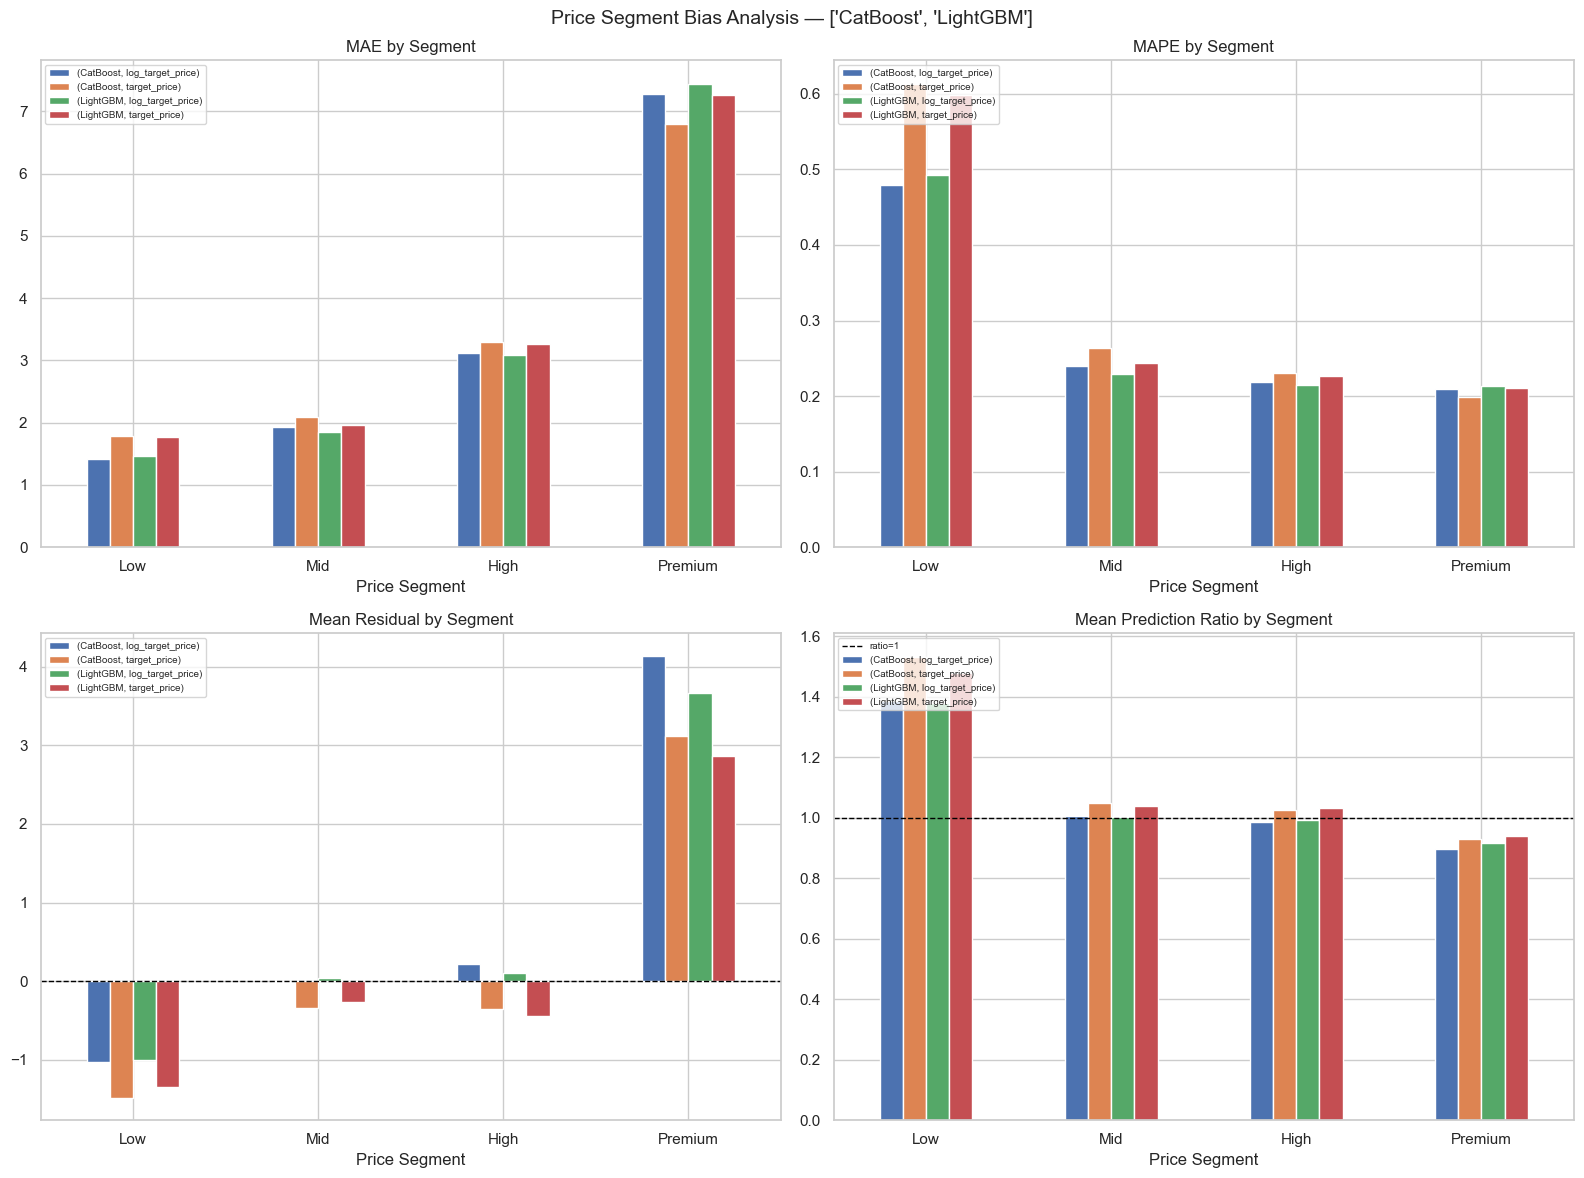

In [17]:
# ── Segment bias plots ─────────────────────────────────────────────────────────
segments_order = ['Low', 'Mid', 'High', 'Premium']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Price Segment Bias Analysis — {SELECTED_MODELS}', fontsize=14)

for ax, metric, title in zip(
    axes.flatten(),
    ['mae', 'mape', 'mean_residual', 'prediction_ratio_mean'],
    ['MAE by Segment', 'MAPE by Segment', 'Mean Residual by Segment', 'Mean Prediction Ratio by Segment'],
):
    pivot = seg_df.pivot_table(index='price_segment', columns=['model_name', 'target_used'], values=metric)
    pivot = pivot.reindex(segments_order)
    pivot.plot(kind='bar', ax=ax, legend=True)
    if metric == 'mean_residual':
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
    if metric == 'prediction_ratio_mean':
        ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='ratio=1')
    ax.set_title(title)
    ax.set_xlabel('Price Segment')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / 'price_segment_bias_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Segment bias interpretation
for model_name in SELECTED_MODELS:
    for target_used in ANALYZED_TARGETS:
        mask = (seg_df["model_name"] == model_name) & (seg_df["target_used"] == target_used)
        s = seg_df[mask].set_index("price_segment")
        if s.empty:
            continue
        print(f"=== {model_name} + {target_used} - Segment Interpretation ===")
        for seg in ["Low", "Premium"]:
            if seg not in s.index:
                continue
            row = s.loc[seg]
            direction = "underpredicts" if row["mean_residual"] > 0 else "overpredicts"
            print(f"  {seg}: mean_residual={row['mean_residual']:,.0f} ({direction}); over_rate={row['overprediction_rate']:.1%}; under_rate={row['underprediction_rate']:.1%}")
        print()


=== CatBoost + log_target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=73.7%; under_rate=26.3%
  Premium: mean_residual=4 (underpredicts); over_rate=32.6%; under_rate=67.4%

=== CatBoost + target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=79.9%; under_rate=20.1%
  Premium: mean_residual=3 (underpredicts); over_rate=35.1%; under_rate=64.9%

=== LightGBM + log_target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=69.9%; under_rate=30.1%
  Premium: mean_residual=4 (underpredicts); over_rate=34.8%; under_rate=65.2%

=== LightGBM + target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=74.0%; under_rate=26.0%
  Premium: mean_residual=3 (underpredicts); over_rate=39.6%; under_rate=60.4%



### Interpretation - Price Segment Bias

The segment table shows whether each available model is systematically high or low in different price bands. This matters because a model can look acceptable overall while consistently overpricing low-price laptops or underpricing premium laptops. In the tuning notebook, optimize and report segment metrics alongside global metrics, especially Low and Premium MAE/MAPE.


## 7. Premium Segment Deep Dive

Tập trung vào laptops thuộc Premium segment (actual price > Q75) để hiểu underprediction pattern. Primary model là model đầu tiên trong `SELECTED_MODELS` với `log_target_price`; so sánh với cùng model dùng `target_price`.

In [19]:
premium_mask = diag_df['price_segment'] == 'Premium'
premium_df   = diag_df[premium_mask].copy()

print('=== Premium Segment — Summary (SELECTED_MODELS) ===')
prem_rows = []
for (model_name, target_used), grp in premium_df.groupby(['model_name', 'target_used'], observed=True):
    yt  = grp['actual_price'].values
    yp  = grp['predicted_price'].values
    res = grp['residual'].values
    prem_rows.append({
        'model_name':            model_name,
        'target_used':           target_used,
        'count':                 len(yt),
        'mae':                   mean_absolute_error(yt, yp),
        'rmse':                  root_mean_squared_error(yt, yp),
        'mape':                  mean_absolute_percentage_error(yt, yp),
        'mean_residual':         res.mean(),
        'underprediction_rate':  (res > 0).mean(),
        'prediction_ratio_mean': grp['prediction_ratio'].mean(),
        'prediction_ratio_median': grp['prediction_ratio'].median(),
    })

prem_summary = pd.DataFrame(prem_rows)
prem_summary.to_csv(DIAGNOSTICS_DIR / 'premium_segment_diagnostics.csv', index=False)
display(prem_summary)

=== Premium Segment — Summary (SELECTED_MODELS) ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,underprediction_rate,prediction_ratio_mean,prediction_ratio_median
0,CatBoost,log_target_price,359,7.2826,9.8938,0.2094,4.1445,0.6741,0.8959,0.8773
1,CatBoost,target_price,359,6.7946,9.2174,0.1983,3.1263,0.6490,0.9279,0.9190
2,LightGBM,log_target_price,359,7.4446,10.2144,0.2127,3.6632,0.6518,0.9161,0.9058
3,LightGBM,target_price,359,7.2680,9.7937,0.2107,2.8597,0.6045,0.9404,0.9196


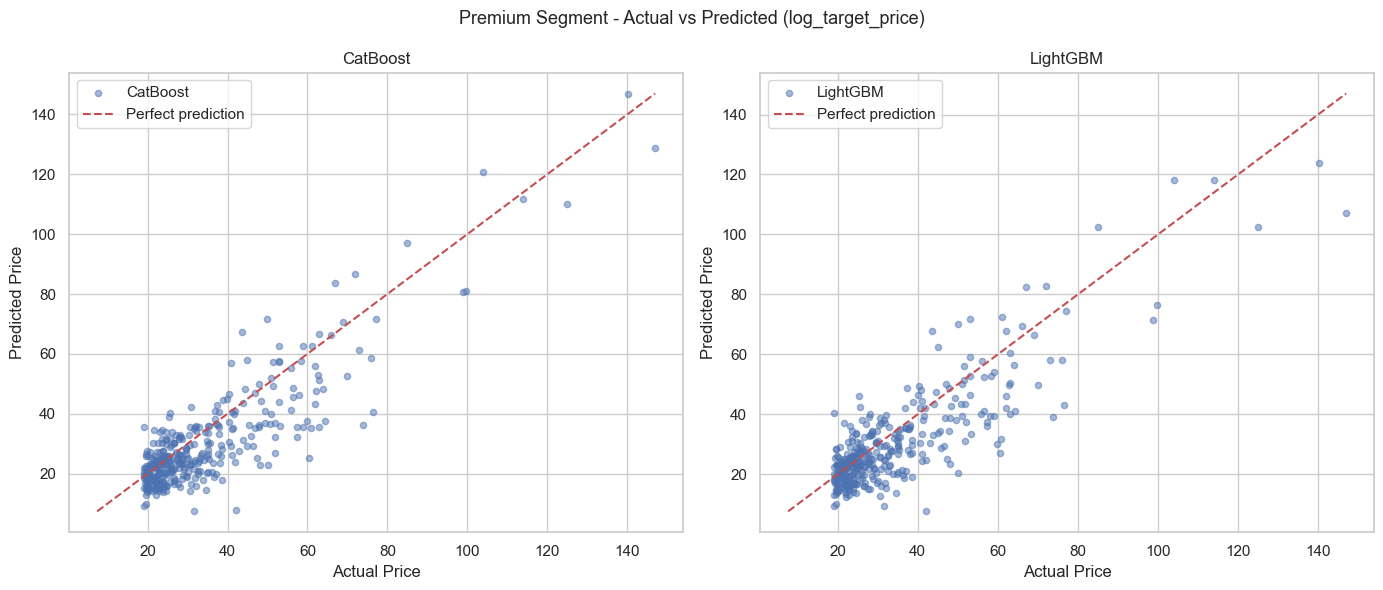

In [20]:
# Premium: actual vs predicted plots for available primary-target models
plot_models = [m for m in SELECTED_MODELS if (m, PRIMARY_TARGET) in available_model_targets]
n_models = len(plot_models)
fig, axes = plt.subplots(1, n_models, figsize=(7 * max(n_models, 1), 6))
if n_models == 1:
    axes = [axes]
fig.suptitle(f"Premium Segment - Actual vs Predicted ({PRIMARY_TARGET})", fontsize=13)

for ax, model_name in zip(axes, plot_models):
    grp = premium_df[(premium_df["model_name"] == model_name) & (premium_df["target_used"] == PRIMARY_TARGET)]
    ax.scatter(grp["actual_price"], grp["predicted_price"], alpha=0.5, s=20, label=model_name)
    lim_min = min(grp["actual_price"].min(), grp["predicted_price"].min())
    lim_max = max(grp["actual_price"].max(), grp["predicted_price"].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_title(model_name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.legend()

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "premium_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
# Premium: top error cases for primary pair
main_premium = premium_df[(premium_df["model_name"] == PRIMARY_MODEL) & (premium_df["target_used"] == PRIMARY_TARGET)].copy()
top20_premium = main_premium.nlargest(20, "absolute_error")
top20_premium.to_csv(DIAGNOSTICS_DIR / "premium_top_error_cases.csv", index=False)
print(f"=== Top 20 Premium Error Cases ({PRIMARY_MODEL} + {PRIMARY_TARGET}) ===")
display(top20_premium[["sample_id", "actual_price", "predicted_price", "residual", "absolute_error", "absolute_percentage_error"]].head(20))


=== Top 20 Premium Error Cases (CatBoost + log_target_price) ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error
944,6544,73.9000,36.2491,37.6509,37.6509,0.5095
1369,5721,76.5000,40.5709,35.9291,35.9291,0.4697
341,6148,60.4900,25.1657,35.3243,35.3243,0.5840
1106,3274,42.0000,7.8654,34.1346,34.1346,0.8127
189,5345,62.9900,35.5829,27.4071,27.4071,0.4351
1298,6740,50.0489,22.7385,27.3104,27.3104,0.5457
1153,6970,64.3900,37.4847,26.9053,26.9053,0.4178
1332,5396,60.9000,35.0859,25.8141,25.8141,0.4239
1378,6122,48.0900,22.9827,25.1073,25.1073,0.5221
843,5767,57.2900,32.2468,25.0432,25.0432,0.4371


### Interpretation - Premium-Segment Underprediction

The premium deep dive isolates whether high-price laptops are systematically predicted below actual prices. This matters because premium errors can dominate RMSE and may affect business trust more than mid-range misses. In the tuning notebook, test raw-target models, premium sample weighting, and segment-aware scoring to reduce high-price underprediction.


## 8. Low-Price Segment Deep Dive

Low-price laptops (actual price ≤ Q25) có thể bị overpredict do mean-reversion effects trong tree models.

In [22]:
low_mask = diag_df["price_segment"] == "Low"
low_df = diag_df[low_mask].copy()

print("=== Low-Price Segment Summary ===")
low_rows = []
for (model_name, target_used), grp in low_df.groupby(["model_name", "target_used"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    low_rows.append({
        "model_name": model_name,
        "target_used": target_used,
        "count": len(grp),
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "mean_residual": metrics["mean_residual"],
        "overprediction_rate": metrics["overprediction_rate"],
        "prediction_ratio_mean": grp["prediction_ratio"].mean(),
    })
low_summary = pd.DataFrame(low_rows)
low_summary.to_csv(DIAGNOSTICS_DIR / "low_price_segment_diagnostics.csv", index=False)
display(low_summary)


=== Low-Price Segment Summary ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,369,1.4163,2.2019,0.4799,-1.0313,0.7371,1.3871
1,CatBoost,target_price,369,1.7912,2.8641,0.6136,-1.4897,0.7995,1.5324
2,LightGBM,log_target_price,369,1.4680,2.3037,0.4920,-1.0079,0.6992,1.3785
3,LightGBM,target_price,369,1.7624,3.0531,0.5989,-1.3530,0.7398,1.4792


In [23]:
# Low-price: top overpredicted cases for primary pair
main_low = low_df[(low_df["model_name"] == PRIMARY_MODEL) & (low_df["target_used"] == PRIMARY_TARGET)].copy()
top_low_over = main_low[main_low["residual"] < 0].nsmallest(20, "residual")
top_low_over.to_csv(DIAGNOSTICS_DIR / "low_price_top_error_cases.csv", index=False)
print("=== Top 20 Overpredicted Low-Price Cases ===")
display(top_low_over[["sample_id", "actual_price", "predicted_price", "residual", "absolute_percentage_error"]].head(20))

over_rate = (main_low["residual"] < 0).mean() if len(main_low) else np.nan
print(f"\nOverprediction rate for Low-price segment ({PRIMARY_MODEL} + {PRIMARY_TARGET}): {over_rate:.1%}")
if over_rate > 0.55:
    print("Model tends to overpredict low-price laptops, consistent with mean-reversion.")
else:
    print("No strong overprediction bias in the low-price segment for the primary pair.")


=== Top 20 Overpredicted Low-Price Cases ===


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error
812,3647,3.5000,17.1843,-13.6843,3.9098
587,696,1.0000,14.3470,-13.3470,13.3470
369,2299,2.7000,14.1506,-11.4506,4.2410
867,3817,5.2000,15.3008,-10.1008,1.9425
671,2155,2.8890,10.9716,-8.0826,2.7977
299,4557,3.2000,10.6124,-7.4124,2.3164
1015,5723,5.5000,12.3909,-6.8909,1.2529
1276,5617,5.5000,12.2743,-6.7743,1.2317
468,3235,5.5000,10.7306,-5.2306,0.9510
228,2114,4.9000,10.1302,-5.2302,1.0674



Overprediction rate for Low-price segment (CatBoost + log_target_price): 73.7%
Model tends to overpredict low-price laptops, consistent with mean-reversion.


### Interpretation - Low-Price Overprediction

The low-price section checks whether inexpensive laptops are pulled upward toward the mean prediction. This matters because high MAPE in the low segment can be hidden by lower absolute prices. In the tuning notebook, monitor low-segment MAPE and consider objectives or weighting that reduce low-price overprediction without worsening premium underprediction.


## 9. Top Error Case Analysis

Xem xét các samples có lỗi lớn nhất để hiểu nguồn gốc sai số — từ price segment cụ thể hay từ data quality issues.

In [24]:
base_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual',
             'absolute_error', 'absolute_percentage_error', 'price_segment']

for model_name in SELECTED_MODELS:
    main_all = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()

    if main_all.empty:
        continue

    top_abs   = main_all.nlargest(30, 'absolute_error')
    top_pct   = main_all.nlargest(30, 'absolute_percentage_error')
    top_under = main_all.nlargest(30, 'residual')
    top_over  = main_all.nsmallest(30, 'residual')

    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    top_abs[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_absolute_error_{fn}.csv', index=False)
    top_pct[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_percentage_error_{fn}.csv', index=False)
    top_under[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_underpredicted_{fn}.csv', index=False)
    top_over[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_overpredicted_{fn}.csv', index=False)

    print(f'=== {model_name} — Top 10 by Absolute Error ===')
    display(top_abs[base_cols].head(10))

    print(f'\n=== {model_name} — Segment distribution in Top 30 Absolute Errors ===')
    print(top_abs['price_segment'].value_counts())
    print()

print('\nSaved: top_absolute_error_*, top_percentage_error_*, top_underpredicted_*, top_overpredicted_*')

=== CatBoost — Top 10 by Absolute Error ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,price_segment
944,6544,73.9000,36.2491,37.6509,37.6509,0.5095,Premium
1369,5721,76.5000,40.5709,35.9291,35.9291,0.4697,Premium
341,6148,60.4900,25.1657,35.3243,35.3243,0.5840,Premium
1106,3274,42.0000,7.8654,34.1346,34.1346,0.8127,Premium
189,5345,62.9900,35.5829,27.4071,27.4071,0.4351,Premium
1298,6740,50.0489,22.7385,27.3104,27.3104,0.5457,Premium
634,6957,12.8900,40.0547,-27.1647,27.1647,2.1074,High
1153,6970,64.3900,37.4847,26.9053,26.9053,0.4178,Premium
1332,5396,60.9000,35.0859,25.8141,25.8141,0.4239,Premium
1378,6122,48.0900,22.9827,25.1073,25.1073,0.5221,Premium



=== CatBoost — Segment distribution in Top 30 Absolute Errors ===
price_segment
Premium    29
High        1
Low         0
Mid         0
Name: count, dtype: int64

=== LightGBM — Top 10 by Absolute Error ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,price_segment
3818,7067,146.9900,107.2495,39.7405,39.7405,0.2704,Premium
3828,6544,73.9000,39.1411,34.7589,34.7589,0.4704,Premium
3990,3274,42.0000,7.6348,34.3652,34.3652,0.8182,Premium
4253,5721,76.5000,43.0921,33.4079,33.4079,0.4367,Premium
3225,6148,60.4900,27.2328,33.2572,33.2572,0.5498,Premium
4097,6555,59.9000,30.0422,29.8578,29.8578,0.4985,Premium
4182,6740,50.0489,20.3823,29.6666,29.6666,0.5928,Premium
4216,5396,60.9000,31.6376,29.2624,29.2624,0.4805,Premium
3757,7199,98.8400,71.5753,27.2647,27.2647,0.2758,Premium
4262,6122,48.0900,23.4481,24.6419,24.6419,0.5124,Premium



=== LightGBM — Segment distribution in Top 30 Absolute Errors ===
price_segment
Premium    29
High        1
Low         0
Mid         0
Name: count, dtype: int64


Saved: top_absolute_error_*, top_percentage_error_*, top_underpredicted_*, top_overpredicted_*


## 10. Log-Target Compression Check

So sánh `log_target_price` vs `target_price` theo price segment để phát hiện xem log-transform có nén prediction ở vùng giá cao không (prediction_ratio < 1 ở Premium).

In [25]:
for model_name in SELECTED_MODELS:
    log_col = f'pred_{safe_filename(model_name, "log_target_price")}'
    raw_col = f'pred_{safe_filename(model_name, "target_price")}'

    if log_col not in predictions_raw.columns or raw_col not in predictions_raw.columns:
        print(f'{model_name}: one or both target columns not found — skipping compression check.')
        continue

    actual   = predictions_raw[actual_col].values
    pred_log = predictions_raw[log_col].values
    pred_raw = predictions_raw[raw_col].values

    comp_df = pd.DataFrame({
        'actual_price':        actual,
        'pred_log':            pred_log,
        'pred_raw':            pred_raw,
        'residual_log':        actual - pred_log,
        'residual_raw':        actual - pred_raw,
        'prediction_ratio_log': pred_log / (actual + 1e-9),
        'prediction_ratio_raw': pred_raw / (actual + 1e-9),
    })
    comp_df['price_segment'] = comp_df['actual_price'].apply(assign_segment)
    comp_df['price_segment'] = pd.Categorical(
        comp_df['price_segment'], categories=['Low', 'Mid', 'High', 'Premium'], ordered=True
    )

    seg_comp = comp_df.groupby('price_segment', observed=True).agg(
        count=('actual_price', 'count'),
        pred_ratio_log_mean=('prediction_ratio_log', 'mean'),
        pred_ratio_raw_mean=('prediction_ratio_raw', 'mean'),
        residual_log_mean=('residual_log', 'mean'),
        residual_raw_mean=('residual_raw', 'mean'),
        underpred_log=('residual_log', lambda x: (x > 0).mean()),
        underpred_raw=('residual_raw', lambda x: (x > 0).mean()),
    ).reset_index()

    seg_comp.to_csv(DIAGNOSTICS_DIR / f'{MODEL_NAME_FOR_FILE.get(model_name, model_name)}_log_vs_raw_compression.csv', index=False)
    print(f'=== {model_name} — Log vs Raw Compression Check by Segment ===')
    display(seg_comp)

    # Interpretation
    if 'Premium' in seg_comp['price_segment'].values:
        prem = seg_comp[seg_comp['price_segment'] == 'Premium'].iloc[0]
        if prem['pred_ratio_log_mean'] < prem['pred_ratio_raw_mean']:
            print(f'  ⚠ Log-target has lower prediction ratio than raw-target in Premium segment.')
            print(f'    → Log-transform compresses high-price predictions — underprediction bias.')
        else:
            print(f'  ✓ Log-target does not compress Premium predictions more than raw-target.')
    print()

=== CatBoost — Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,369,1.3871,1.5324,-1.0313,-1.4897,0.2629,0.2005
1,Mid,353,1.0054,1.0485,-0.0095,-0.3438,0.5609,0.5127
2,High,361,0.9867,1.0251,0.2165,-0.3498,0.5734,0.5429
3,Premium,359,0.8959,0.9279,4.1445,3.1263,0.6741,0.6490


  ⚠ Log-target has lower prediction ratio than raw-target in Premium segment.
    → Log-transform compresses high-price predictions — underprediction bias.

=== LightGBM — Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,369,1.3785,1.4792,-1.0079,-1.3530,0.3008,0.2602
1,Mid,353,1.0006,1.0398,0.0371,-0.2672,0.5666,0.5354
2,High,361,0.9933,1.0309,0.1035,-0.4501,0.5762,0.5429
3,Premium,359,0.9161,0.9404,3.6632,2.8597,0.6518,0.6045


  ⚠ Log-target has lower prediction ratio than raw-target in Premium segment.
    → Log-transform compresses high-price predictions — underprediction bias.



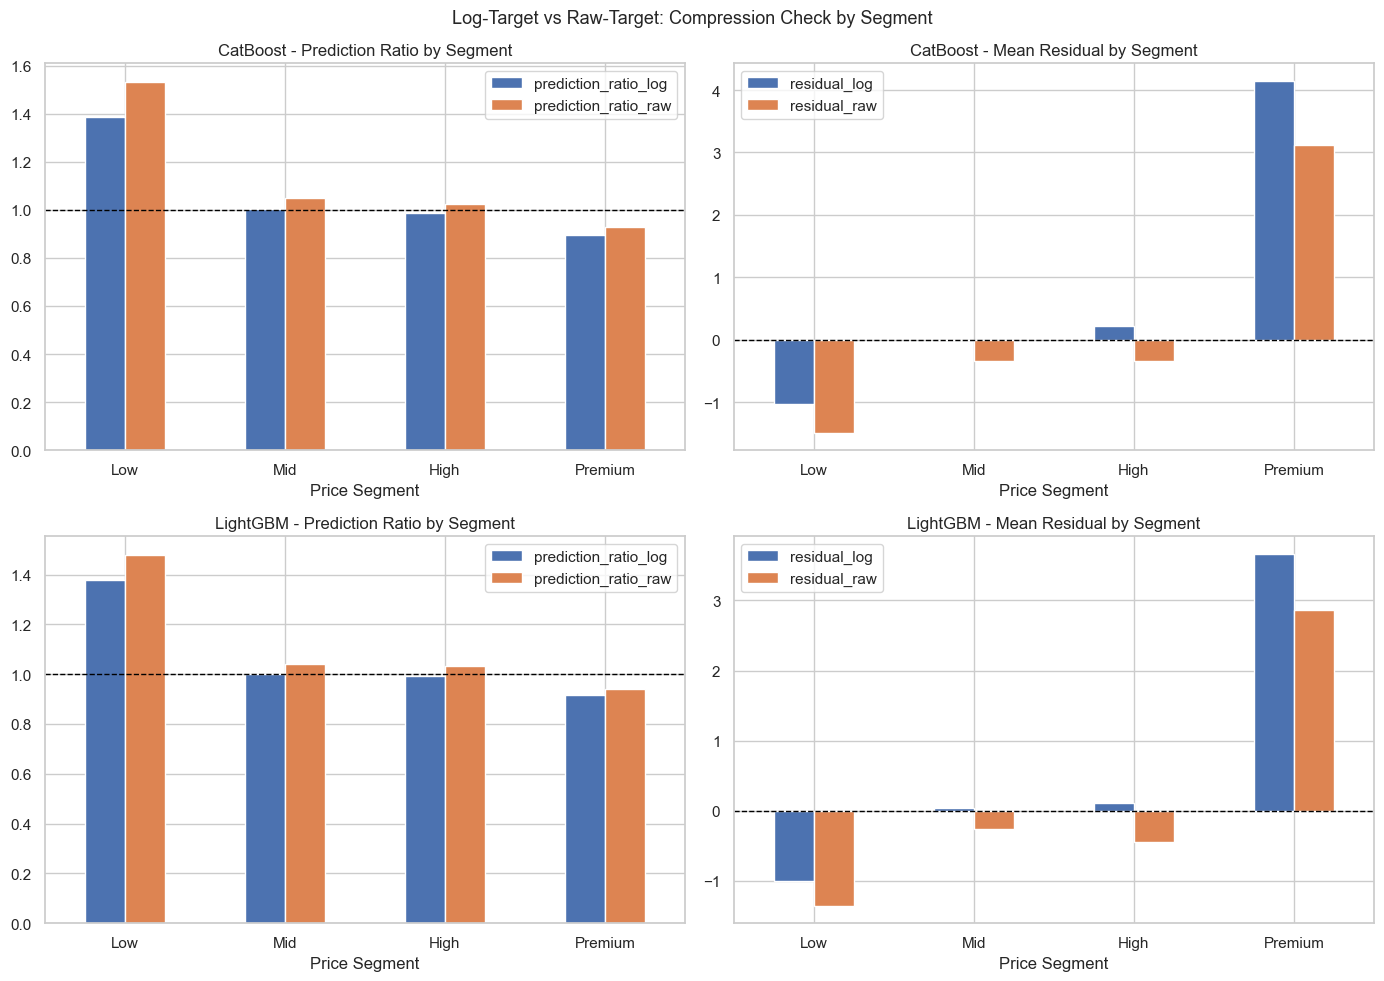

In [26]:
# Compression plots: compare available models with both targets present
compression_models = [m for m in SELECTED_MODELS if (m, "log_target_price") in available_model_targets and (m, "target_price") in available_model_targets]
if compression_models:
    fig, axes = plt.subplots(len(compression_models), 2, figsize=(14, 5 * len(compression_models)))
    if len(compression_models) == 1:
        axes = np.array([axes])
    fig.suptitle("Log-Target vs Raw-Target: Compression Check by Segment", fontsize=13)
    for ax_row, model_name in zip(axes, compression_models):
        log_col = expected_prediction_col(model_name, "log_target_price")
        raw_col = expected_prediction_col(model_name, "target_price")
        actual = predictions_raw[actual_col].values
        pred_log = predictions_raw[log_col].values
        pred_raw = predictions_raw[raw_col].values
        comp_tmp = pd.DataFrame({
            "actual_price": actual,
            "prediction_ratio_log": pred_log / (actual + 1e-9),
            "prediction_ratio_raw": pred_raw / (actual + 1e-9),
            "residual_log": actual - pred_log,
            "residual_raw": actual - pred_raw,
        })
        comp_tmp["price_segment"] = pd.Categorical(comp_tmp["actual_price"].apply(assign_segment), categories=["Low", "Mid", "High", "Premium"], ordered=True)
        seg_c = comp_tmp.groupby("price_segment", observed=True)[["prediction_ratio_log", "prediction_ratio_raw", "residual_log", "residual_raw"]].mean()
        seg_c[["prediction_ratio_log", "prediction_ratio_raw"]].plot(kind="bar", ax=ax_row[0], title=f"{model_name} - Prediction Ratio by Segment")
        ax_row[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
        ax_row[0].set_xlabel("Price Segment")
        ax_row[0].tick_params(axis="x", rotation=0)
        seg_c[["residual_log", "residual_raw"]].plot(kind="bar", ax=ax_row[1], title=f"{model_name} - Mean Residual by Segment")
        ax_row[1].axhline(0, color="black", linestyle="--", linewidth=1)
        ax_row[1].set_xlabel("Price Segment")
        ax_row[1].tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / "log_vs_raw_compression_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No model has both log_target_price and target_price prediction columns; compression plot skipped.")


### Interpretation - Log-Target Compression

The compression check compares log-target and raw-target predictions by segment. If the log-target prediction ratio falls below the raw-target ratio in Premium, the log transform is compressing high-price predictions. In the tuning notebook, keep both target strategies as candidates and choose with segment-aware validation rather than global RMSE alone.


## 11. Outlier and Data Quality Investigation

Flag các cases có thể là data quality issues. Tiêu chí:

- Absolute percentage error > 200%
- Actual price cao nhưng predicted price rất thấp (prediction_ratio < 0.5)
- Actual price thấp nhưng predicted price rất cao (prediction_ratio > 2.0)

> **Lưu ý**: Không xóa records ở notebook này. Chỉ flag để review thủ công.

In [27]:
for model_name in SELECTED_MODELS:
    main_for_outliers = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()

    if main_for_outliers.empty:
        continue

    outlier_flags = (
        (main_for_outliers['absolute_percentage_error'] > 2.0) |
        (main_for_outliers['prediction_ratio'] < 0.5) |
        (main_for_outliers['prediction_ratio'] > 2.0)
    )

    potential_outliers = main_for_outliers[outlier_flags].copy()
    print(f'{model_name}: {len(potential_outliers)} potential outliers of {len(main_for_outliers)}')

    out_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual',
                'absolute_percentage_error', 'prediction_ratio', 'price_segment']

    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    potential_outliers[out_cols].to_csv(
        DIAGNOSTICS_DIR / f'potential_outliers_{fn}.csv', index=False
    )

    display(
        potential_outliers[out_cols]
        .sort_values('absolute_percentage_error', ascending=False)
        .head(10)
    )
    print(f'  Saved: potential_outliers_{fn}.csv\n')

CatBoost: 60 potential outliers of 1442


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
587,696,1.0000,14.3470,-13.3470,13.3470,14.3470,Low
369,2299,2.7000,14.1506,-11.4506,4.2410,5.2410,Low
812,3647,3.5000,17.1843,-13.6843,3.9098,4.9098,Low
1102,373,1.3000,5.8704,-4.5704,3.5157,4.5157,Low
671,2155,2.8890,10.9716,-8.0826,2.7977,3.7977,Low
818,2794,1.3500,4.6780,-3.3280,2.4652,3.4652,Low
904,3169,2.2000,7.3784,-5.1784,2.3538,3.3538,Low
82,5823,7.2900,24.1829,-16.8929,2.3173,3.3173,Mid
299,4557,3.2000,10.6124,-7.4124,2.3164,3.3164,Low
24,1979,1.1000,3.5202,-2.4202,2.2001,3.2001,Low


  Saved: potential_outliers_CatBoost.csv

LightGBM: 70 potential outliers of 1442


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
3471,696,1.0000,14.3711,-13.3711,13.3711,14.3711,Low
3253,2299,2.7000,16.1153,-13.4153,4.9686,5.9686,Low
3986,373,1.3000,7.3365,-6.0365,4.6434,5.6434,Low
3696,3647,3.5000,18.1567,-14.6567,4.1876,5.1876,Low
2908,1979,1.1000,3.9854,-2.8854,2.6231,3.6231,Low
3788,3169,2.2000,7.8646,-5.6646,2.5748,3.5748,Low
3702,2794,1.3500,4.5654,-3.2154,2.3818,3.3818,Low
3475,157,2.0500,6.8420,-4.7920,2.3376,3.3376,Low
3183,4557,3.2000,10.6731,-7.4731,2.3354,3.3354,Low
3555,2155,2.8890,8.7553,-5.8663,2.0306,3.0306,Low


  Saved: potential_outliers_LightGBM.csv



### Interpretation - Outlier and Data Quality Checks

The outlier tables flag cases with extreme percentage error or implausible prediction ratios. This matters because a few mislabeled or unusual listings can distort RMSE and segment conclusions. In the tuning notebook, review flagged rows manually and test sensitivity with and without verified bad records, but do not remove cases solely because the model missed them.


## 12. Exploratory Correction Strategy Experiments

> **Warning**: Các thử nghiệm này chỉ mang tính exploratory. Corrections được compute và evaluate trên cùng test set, nên metrics là test-set optimistic và không nên report như final model performance.

Ba chiến lược post-hoc correction được test:

1. **Additive segment correction**: cộng mean residual theo segment
2. **Multiplicative segment correction**: chia prediction cho median prediction ratio theo segment
3. **Premium-only correction**: chỉ áp dụng correction cho Premium laptops

Any correction method should be validated with cross-validation or a separate validation split in the next tuning notebook.


In [28]:
def evaluate_correction(actual, predicted_corrected, name):
    metrics = compute_error_metrics(actual, predicted_corrected)
    return {
        "correction": name,
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "median_absolute_error": metrics["median_absolute_error"],
        "mean_residual": metrics["mean_residual"],
        "underprediction_rate": metrics["underprediction_rate"],
        "severe_error_rate": metrics["severe_error_rate"],
        "extreme_error_rate": metrics["extreme_error_rate"],
        "r2": r2_score(actual, predicted_corrected),
    }

all_corr_results = {}
for model_name in SELECTED_MODELS:
    base = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == PRIMARY_TARGET)].copy()
    if base.empty:
        continue
    actual_arr = base["actual_price"].values
    predicted_arr = base["predicted_price"].values
    seg_stats = base.groupby("price_segment", observed=True).agg(mean_residual=("residual", "mean"), median_ratio=("prediction_ratio", "median")).to_dict("index")
    pred_additive = predicted_arr.copy()
    pred_multiplicative = predicted_arr.copy()
    pred_premium_only = predicted_arr.copy()
    for i, (seg, row) in enumerate(zip(base["price_segment"], predicted_arr)):
        key = str(seg)
        if key in seg_stats:
            pred_additive[i] = row + seg_stats[key]["mean_residual"]
            ratio = seg_stats[key]["median_ratio"]
            if ratio > 0:
                pred_multiplicative[i] = row / ratio
        if key == "Premium" and "Premium" in seg_stats:
            pred_premium_only[i] = row + seg_stats["Premium"]["mean_residual"]
    corr_df = pd.DataFrame([
        evaluate_correction(actual_arr, predicted_arr, "No correction (baseline)"),
        evaluate_correction(actual_arr, pred_additive, "Additive segment correction"),
        evaluate_correction(actual_arr, pred_multiplicative, "Multiplicative segment correction"),
        evaluate_correction(actual_arr, pred_premium_only, "Premium-only additive correction"),
    ])
    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    corr_df.to_csv(DIAGNOSTICS_DIR / f"correction_experiment_{fn}.csv", index=False)
    all_corr_results[model_name] = corr_df
    print(f"=== {model_name} - Exploratory Correction Results (test-set optimistic) ===")
    display(corr_df)
    print("Validate any correction via cross-validation or a held-out validation split before reporting.\n")


=== CatBoost - Exploratory Correction Results (test-set optimistic) ===


,correction,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate,r2
0,No correction (baseline),3.4317,5.6352,0.2884,1.9225,0.8198,0.5160,0.1297,0.0250,0.8575
1,Additive segment correction,3.2655,5.2149,0.2676,1.8821,0.0000,0.5465,0.1110,0.0153,0.8780
2,Multiplicative segment correction,3.3883,5.6063,0.2599,1.8205,-0.2948,0.4986,0.0978,0.0160,0.8590
3,Premium-only additive correction,3.3062,5.2421,0.2867,1.9533,-0.2120,0.4639,0.1325,0.0257,0.8767


Validate any correction via cross-validation or a held-out validation split before reporting.

=== LightGBM - Exploratory Correction Results (test-set optimistic) ===


,correction,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate,r2
0,No correction (baseline),3.4507,5.7644,0.2889,1.8571,0.6891,0.5222,0.1227,0.0333,0.8509
1,Additive segment correction,3.3256,5.4428,0.2749,1.8341,0.0000,0.5499,0.1234,0.0208,0.8671
2,Multiplicative segment correction,3.3894,5.6584,0.2623,1.7900,-0.1389,0.4986,0.1033,0.0208,0.8564
3,Premium-only additive correction,3.3545,5.4669,0.2881,1.8600,-0.2229,0.4730,0.1262,0.0333,0.8659


Validate any correction via cross-validation or a held-out validation split before reporting.



In [29]:
# ── Premium metrics after each correction ─────────────────────────────────────
for model_name in SELECTED_MODELS:
    base = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()
    if base.empty:
        continue

    actual_arr    = base['actual_price'].values
    predicted_arr = base['predicted_price'].values

    seg_stats = base.groupby('price_segment', observed=True).agg(
        mean_residual=('residual', 'mean'),
        median_ratio=('prediction_ratio', 'median'),
    ).to_dict('index')

    pred_additive       = predicted_arr.copy()
    pred_multiplicative = predicted_arr.copy()
    pred_premium_only   = predicted_arr.copy()

    for i, (seg, row) in enumerate(zip(base['price_segment'], predicted_arr)):
        key = str(seg)
        if key in seg_stats:
            pred_additive[i] = row + seg_stats[key]['mean_residual']
            r = seg_stats[key]['median_ratio']
            if r > 0:
                pred_multiplicative[i] = row / r
        if key == 'Premium' and 'Premium' in seg_stats:
            pred_premium_only[i] = row + seg_stats['Premium']['mean_residual']

    prem_idx    = base['price_segment'].astype(str) == 'Premium'
    prem_actual = actual_arr[prem_idx]

    prem_correction_results = []
    for pred_arr_variant, label in [
        (predicted_arr,      'No correction'),
        (pred_additive,      'Additive'),
        (pred_multiplicative,'Multiplicative'),
        (pred_premium_only,  'Premium-only'),
    ]:
        prem_pred = pred_arr_variant[prem_idx]
        if len(prem_pred) == 0:
            continue
        prem_correction_results.append({
            'correction':              label,
            'premium_mae':             mean_absolute_error(prem_actual, prem_pred),
            'premium_rmse':            root_mean_squared_error(prem_actual, prem_pred),
            'premium_mape':            mean_absolute_percentage_error(prem_actual, prem_pred),
            'premium_underprediction_rate': ((prem_actual - prem_pred) > 0).mean(),
        })

    print(f'=== {model_name} — Premium Segment Metrics After Corrections ===')
    display(pd.DataFrame(prem_correction_results))
    print('Note: test-set estimates only. Validate via cross-validation in next tuning notebook.\n')

=== CatBoost — Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,7.2826,9.8938,0.2094,0.6741
1,Additive,6.7789,8.9839,0.2025,0.4652
2,Multiplicative,7.2937,9.7854,0.2164,0.4986
3,Premium-only,6.7789,8.9839,0.2025,0.4652


Note: test-set estimates only. Validate via cross-validation in next tuning notebook.

=== LightGBM — Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,7.4446,10.2144,0.2127,0.6518
1,Additive,7.0580,9.5350,0.2096,0.4540
2,Multiplicative,7.3978,9.9681,0.2187,0.4986
3,Premium-only,7.0580,9.5350,0.2096,0.4540


Note: test-set estimates only. Validate via cross-validation in next tuning notebook.



### Interpretation - Exploratory Correction Strategies

The correction tables show whether simple segment-level calibration can reduce observed bias on the same test data. This matters because a large apparent gain may indicate a real residual pattern, but the estimate is optimistic because the correction was learned from the evaluated data. In the tuning notebook, validate any correction through cross-validation, a calibration split, or a residual model trained without peeking at the test set.


## 13. Available Model Comparison

So sánh trực tiếp các model-target combinations thực sự có prediction columns. Requested models without predictions are excluded and documented in validation.


In [30]:
# Overall metrics comparison by target
for target_used in ANALYZED_TARGETS:
    target_summary = summary_df[summary_df["target_used"] == target_used]
    if target_summary.empty:
        continue
    print(f"=== Overall Metrics Comparison - {target_used} ===")
    display(target_summary[["model_name", "mae", "rmse", "mape", "median_absolute_error", "mean_residual", "underprediction_rate", "severe_error_rate", "extreme_error_rate"]].sort_values("rmse"))


=== Overall Metrics Comparison - log_target_price ===


,model_name,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate
1,CatBoost,3.4317,5.6352,0.2884,1.9225,0.8198,0.5160,0.1297,0.0250
2,LightGBM,3.4507,5.7644,0.2889,1.8571,0.6891,0.5222,0.1227,0.0333


=== Overall Metrics Comparison - target_price ===


,model_name,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate
0,CatBoost,3.4887,5.5146,0.3285,2.1175,0.2254,0.4743,0.1581,0.0451
3,LightGBM,3.5544,5.7763,0.3222,1.9777,0.1876,0.4840,0.1463,0.0430


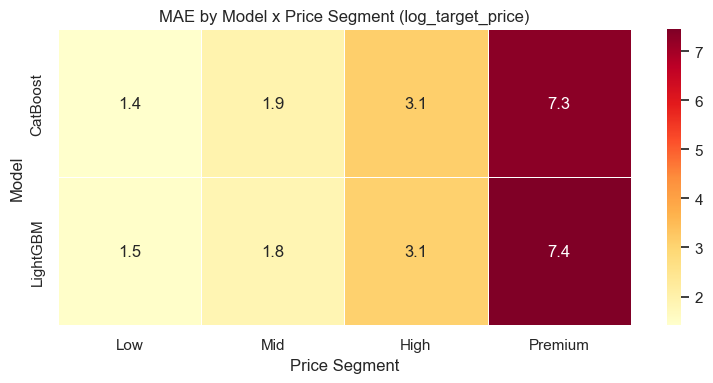

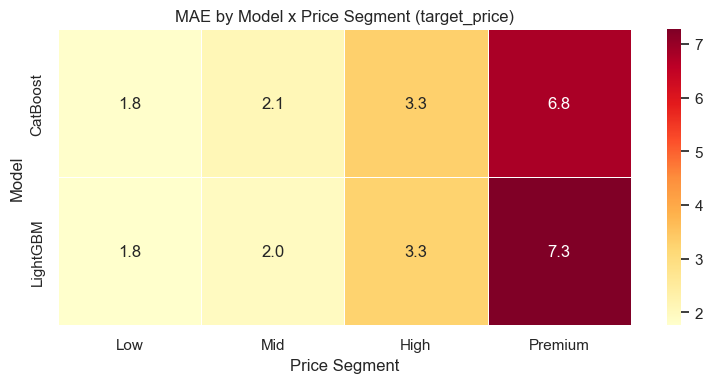

In [31]:
# Segment MAE heatmap: model x segment
for target_used in ANALYZED_TARGETS:
    pivot_mae = seg_df[seg_df["target_used"] == target_used].pivot_table(index="model_name", columns="price_segment", values="mae").reindex(columns=["Low", "Mid", "High", "Premium"])
    if pivot_mae.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot_mae, annot=True, fmt=",.1f", cmap="YlOrRd", linewidths=0.5, ax=ax)
    ax.set_title(f"MAE by Model x Price Segment ({target_used})")
    ax.set_xlabel("Price Segment")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / f"mae_heatmap_{target_used}.png", dpi=150, bbox_inches="tight")
    plt.show()


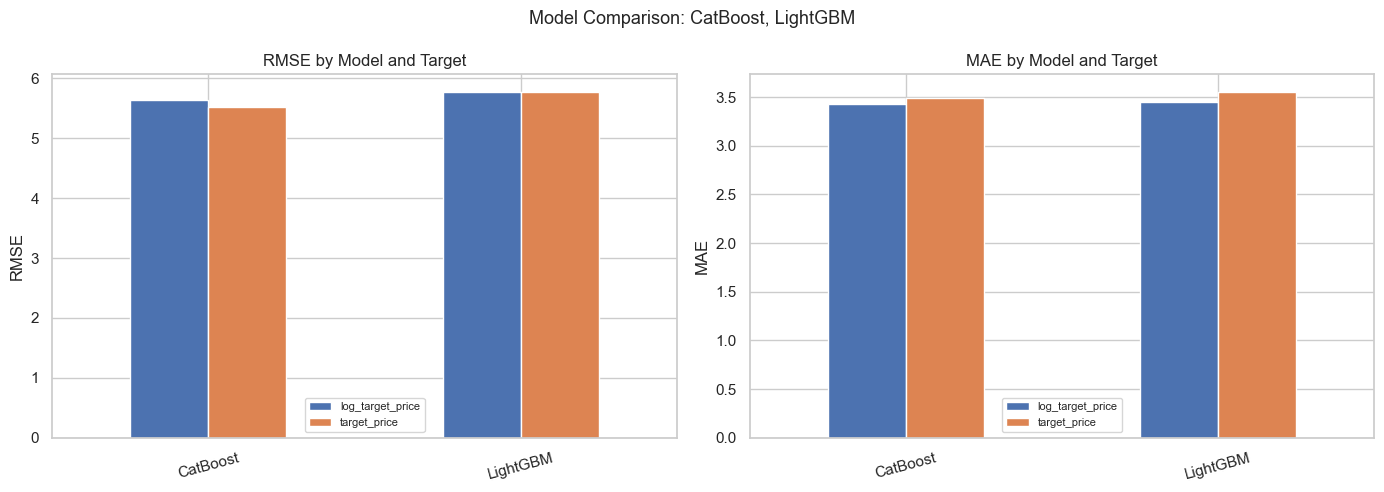

In [32]:
# Bar chart: RMSE and MAE by available model-target combinations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Model Comparison: {', '.join(SELECTED_MODELS)}", fontsize=13)
for ax, metric in zip(axes, ["rmse", "mae"]):
    pivot = summary_df.pivot_table(index="model_name", columns="target_used", values=metric)
    pivot.plot(kind="bar", ax=ax, title=f"{metric.upper()} by Model and Target")
    ax.set_xlabel("")
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Diagnostic Summary and Recommendations

Tổng hợp findings và recommended actions dựa trên diagnostics ở trên.


In [33]:
# Auto-generate ranking by available target
rankings = {}
for target_used in ANALYZED_TARGETS:
    ranked = summary_df[summary_df["target_used"] == target_used].sort_values("rmse").reset_index(drop=True)
    rankings[target_used] = ranked
    print(f"=== Ranking by RMSE ({target_used}) ===")
    for i, row in ranked.iterrows():
        print(f"  #{i+1}: {row['model_name']}  RMSE={row['rmse']:,.4f}  MAE={row['mae']:,.4f}  MAPE={row['mape']:.1%}")
    print()


=== Ranking by RMSE (log_target_price) ===
  #1: CatBoost  RMSE=5.6352  MAE=3.4317  MAPE=28.8%
  #2: LightGBM  RMSE=5.7644  MAE=3.4507  MAPE=28.9%

=== Ranking by RMSE (target_price) ===
  #1: CatBoost  RMSE=5.5146  MAE=3.4887  MAPE=32.9%
  #2: LightGBM  RMSE=5.7763  MAE=3.5544  MAPE=32.2%



In [34]:
analyzed_pairs_text = format_model_target_pairs(available_model_targets)
skipped_text = "; ".join(f"{m}+{t} missing {col}" for m, t, col in skipped_model_targets) or "None"
recommendation_text = f"""
=============================================================
MODEL DIAGNOSTICS RECOMMENDATIONS
Notebook: 10_model_diagnostics_and_error_analysis.ipynb
Dataset : numeric features only (laptop_processed_numeric.csv)
Analyzed: {analyzed_pairs_text}
Skipped : {skipped_text}
=============================================================

CONFIRMED FINDINGS
------------------
1. Heteroscedasticity: check residual plots, binned error summaries, and Spearman tests.
2. Premium segment underprediction: tune explicitly if Premium residuals are positive and ratios are below 1.
3. Low-price overprediction: monitor Low MAPE and overprediction rate during tuning.
4. Log-target trade-off: compare log_target_price and target_price only for models where both columns exist.

RECOMMENDATIONS FOR TUNING NOTEBOOK
-----------------------------------
1. Tune only model-target pairs with available predictions unless notebook 07b is rerun to produce missing columns.
2. Use cross-validation or a validation split, evaluated on original price scale.
3. Track Overall, Low, and Premium MAE/RMSE/MAPE, plus mean residual and underprediction rate.
4. Consider sample weighting for Premium cases if high-price underprediction persists.
5. Treat correction experiments as exploratory only; validate calibration out-of-sample before reporting.
6. Review potential outliers manually before excluding any records.
"""
print(recommendation_text)
rec_path = DIAGNOSTICS_DIR / "model_diagnostics_recommendation.txt"
rec_path.write_text(recommendation_text.strip(), encoding="utf-8")
print(f"\nSaved: {rec_path}")



MODEL DIAGNOSTICS RECOMMENDATIONS
Notebook: 10_model_diagnostics_and_error_analysis.ipynb
Dataset : numeric features only (laptop_processed_numeric.csv)
Analyzed: CatBoost + log_target_price, CatBoost + target_price, LightGBM + log_target_price, LightGBM + target_price
Skipped : XGBoost+log_target_price missing pred_XGBoost_log_target_price; XGBoost+target_price missing pred_XGBoost_target_price

CONFIRMED FINDINGS
------------------
1. Heteroscedasticity: check residual plots, binned error summaries, and Spearman tests.
2. Premium segment underprediction: tune explicitly if Premium residuals are positive and ratios are below 1.
3. Low-price overprediction: monitor Low MAPE and overprediction rate during tuning.
4. Log-target trade-off: compare log_target_price and target_price only for models where both columns exist.

RECOMMENDATIONS FOR TUNING NOTEBOOK
-----------------------------------
1. Tune only model-target pairs with available predictions unless notebook 07b is rerun to prod

In [35]:
# Final diagnostic summary table and output file summary
best_overall = summary_df.sort_values("rmse").iloc[0]
primary_seg = seg_df[(seg_df["model_name"] == PRIMARY_MODEL) & (seg_df["target_used"] == PRIMARY_TARGET)].set_index("price_segment")
premium_row = primary_seg.loc["Premium"] if "Premium" in primary_seg.index else None
low_row = primary_seg.loc["Low"] if "Low" in primary_seg.index else None
hetero_row = hetero_evidence_df[hetero_evidence_df["model_name"] == PRIMARY_MODEL].iloc[0] if not hetero_evidence_df.empty and PRIMARY_MODEL in hetero_evidence_df["model_name"].values else None
outlier_files = sorted(DIAGNOSTICS_DIR.glob("potential_outliers_*.csv"))
correction_files = sorted(DIAGNOSTICS_DIR.glob("correction_experiment_*.csv"))
final_diagnostic_summary = pd.DataFrame([
    {"Diagnostic Area": "Overall error", "Main Finding": f"Best available pair is {best_overall['model_name']} + {best_overall['target_used']} by RMSE.", "Evidence": f"RMSE={best_overall['rmse']:,.2f}; MAE={best_overall['mae']:,.2f}; MAPE={best_overall['mape']:.1%}", "Risk": "Global metrics can hide segment bias.", "Recommended Next Action": "Tune candidates using both global and segment-level validation metrics."},
    {"Diagnostic Area": "Segment bias", "Main Finding": "Bias varies by price segment for the primary diagnostic pair.", "Evidence": "See price_segment_bias_summary.csv and price_segment_bias_plots.png.", "Risk": "A globally strong model may fail in Low or Premium segments.", "Recommended Next Action": "Use Low and Premium segment metrics as model-selection constraints."},
    {"Diagnostic Area": "Premium underprediction", "Main Finding": "Premium segment shows underprediction if mean residual is positive and prediction ratio is below 1.", "Evidence": "n/a" if premium_row is None else f"mean_residual={premium_row['mean_residual']:,.2f}; underprediction_rate={premium_row['underprediction_rate']:.1%}; ratio={premium_row['prediction_ratio_mean']:.3f}", "Risk": "High-price misses can dominate RMSE and reduce trust in premium estimates.", "Recommended Next Action": "Test premium sample weighting and compare raw-target versus log-target models."},
    {"Diagnostic Area": "Low-price overprediction", "Main Finding": "Low segment shows overprediction if mean residual is negative and overprediction rate is high.", "Evidence": "n/a" if low_row is None else f"mean_residual={low_row['mean_residual']:,.2f}; overprediction_rate={low_row['overprediction_rate']:.1%}; ratio={low_row['prediction_ratio_mean']:.3f}", "Risk": "Low-price MAPE can become large even when absolute errors look modest.", "Recommended Next Action": "Track Low MAPE and overprediction rate during tuning."},
    {"Diagnostic Area": "Heteroscedasticity", "Main Finding": "Error magnitude may change with actual price.", "Evidence": "n/a" if hetero_row is None else f"Spearman rho={hetero_row['rho_abs_error']:.3f}; p={hetero_row['p_value']:.4f}; flag={hetero_row['heteroscedasticity_flag']}", "Risk": "RMSE may overweight expensive laptops and understate low-price relative error.", "Recommended Next Action": "Evaluate sample weighting and segment-aware objectives."},
    {"Diagnostic Area": "Log-target compression", "Main Finding": "Log-target compression is assessed only for models with both target prediction columns.", "Evidence": "See *_log_vs_raw_compression.csv and log_vs_raw_compression_plot.png when generated.", "Risk": "Log target may reduce global error while compressing premium predictions.", "Recommended Next Action": "Keep both target strategies in cross-validated tuning."},
    {"Diagnostic Area": "Potential outliers", "Main Finding": "Extreme errors and prediction ratios were flagged for manual review.", "Evidence": f"Generated {len(outlier_files)} potential_outliers CSV files.", "Risk": "Unverified data issues can distort tuning decisions.", "Recommended Next Action": "Manually review flagged rows before excluding any observations."},
    {"Diagnostic Area": "Correction experiments", "Main Finding": "Segment corrections are exploratory and test-set optimistic.", "Evidence": f"Generated {len(correction_files)} correction experiment CSV files.", "Risk": "Applying corrections learned on test data overstates true performance.", "Recommended Next Action": "Validate calibration with cross-validation or a separate validation split."},
])
summary_path = DIAGNOSTICS_DIR / "final_diagnostic_summary.csv"
final_diagnostic_summary.to_csv(summary_path, index=False)
display(final_diagnostic_summary)
print("=== Output Files Saved ===")
for f in sorted(DIAGNOSTICS_DIR.iterdir()):
    exists = f.exists()
    size_kb = f.stat().st_size / 1024 if exists else 0
    print(f"  {f} | exists={exists} | size={size_kb:,.1f} KB")


,Diagnostic Area,Main Finding,Evidence,Risk,Recommended Next Action
0,Overall error,Best available pair is CatBoost + target_price...,RMSE=5.51; MAE=3.49; MAPE=32.9%,Global metrics can hide segment bias.,Tune candidates using both global and segment-...
1,Segment bias,Bias varies by price segment for the primary d...,See price_segment_bias_summary.csv and price_s...,A globally strong model may fail in Low or Pre...,Use Low and Premium segment metrics as model-s...
2,Premium underprediction,Premium segment shows underprediction if mean ...,mean_residual=4.14; underprediction_rate=67.4%...,High-price misses can dominate RMSE and reduce...,Test premium sample weighting and compare raw-...
3,Low-price overprediction,Low segment shows overprediction if mean resid...,mean_residual=-1.03; overprediction_rate=73.7%...,Low-price MAPE can become large even when abso...,Track Low MAPE and overprediction rate during ...
4,Heteroscedasticity,Error magnitude may change with actual price.,Spearman rho=0.534; p=0.0000; flag=True,RMSE may overweight expensive laptops and unde...,Evaluate sample weighting and segment-aware ob...
5,Log-target compression,Log-target compression is assessed only for mo...,See *_log_vs_raw_compression.csv and log_vs_ra...,Log target may reduce global error while compr...,Keep both target strategies in cross-validated...
6,Potential outliers,Extreme errors and prediction ratios were flag...,Generated 2 potential_outliers CSV files.,Unverified data issues can distort tuning deci...,Manually review flagged rows before excluding ...
7,Correction experiments,Segment corrections are exploratory and test-s...,Generated 2 correction experiment CSV files.,Applying corrections learned on test data over...,Validate calibration with cross-validation or ...


=== Output Files Saved ===
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\CatBoost_log_vs_raw_compression.csv | exists=True | size=0.6 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\correction_experiment_CatBoost.csv | exists=True | size=0.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\correction_experiment_LightGBM.csv | exists=True | size=0.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_errors_long.csv | exists=True | size=977.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_model_error_summary.csv | exists=True | size=1.1 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\final_diagnostic_summary.csv | exists=True | size=2.2 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\heteroscedasticity_binned_error_summary